# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skripiy/ida-practice-3d/blob/main/practice/3/3-homework-results.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("mode.string_storage", "python")   # see the note below
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__,
      "| pandas", pd.__version__)

# Why the string_storage line: on pandas 3 a text column such as iris's
# "Species" is the `str` dtype, and if pyarrow is installed that dtype is
# Arrow-backed, so `Series.values` hands scikit-learn an ArrowStringArray.
# Indexing one of those by an array of row positions -- which is what every
# cross-validation split does -- raises
#     TypeError: only integer scalar arrays can be converted to a scalar index
# Task 6 hits it first. Python-backed strings give the object array
# scikit-learn expects. Colab and the dev-env image have no pyarrow, so this
# line is a no-op there.

python 3.14.6 | scikit-learn 1.9.1 | pandas 3.0.3


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


In [3]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
iris = pd.read_csv("../datasets/iris.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [4]:
def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'.

        mse  = mean of the squared errors
        rmse = square root of mse
        mae  = mean of the absolute errors
        r2   = 1 - (sum of squared errors) / (sum of squared deviations
               of y_true from its own mean)

    Return Python/NumPy floats. Do not import from sklearn.metrics.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    errors = y_true - y_pred
    mse = float(np.mean(errors ** 2))

    # The denominator of R^2 is the error of the model that always predicts
    # the mean, which is why predicting the mean scores exactly 0.
    ss_error = float(np.sum(errors ** 2))
    ss_total = float(np.sum((y_true - y_true.mean()) ** 2))

    return {
        "mse": mse,
        "rmse": float(np.sqrt(mse)),
        "mae": float(np.mean(np.abs(errors))),
        "r2": 1.0 - ss_error / ss_total,
    }

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

temp + hum + windspeed -> cnt, 75/25 split
{'mse': 25094.1254, 'rmse': 158.4113, 'mae': 118.9047, 'r2': 0.2511}

RMSE / MAE = 1.3323
the target itself: mean 189.5, std 181.4, min 1, max 977
predictions range from -36.6 to 491.3  -> 19 of 4345 are negative

the ten worst-predicted hours:
 hr  workingday  temp_C  actual  predicted  residual  abs_residual
 17           1 27.0600     905   232.4000  672.5800      672.5800
 17           1 28.7000     917   254.8000  662.2300      662.2300
  8           1 21.3200     801   141.3000  659.6700      659.6700
  8           1 22.9600     838   185.3000  652.7100      652.7100
  8           1 25.4200     809   163.7000  645.2800      645.2800
 17           1 27.8800     938   313.5000  624.4700      624.4700
  8           1 18.0400     700    81.1000  618.9100      618.9100
 17           1 28.7000     893   277.0000  616.0300      616.0300
  8           1 18.8600     761   149.7000  611.2600      611.2600
  8           1 17.2200     745   138.0000

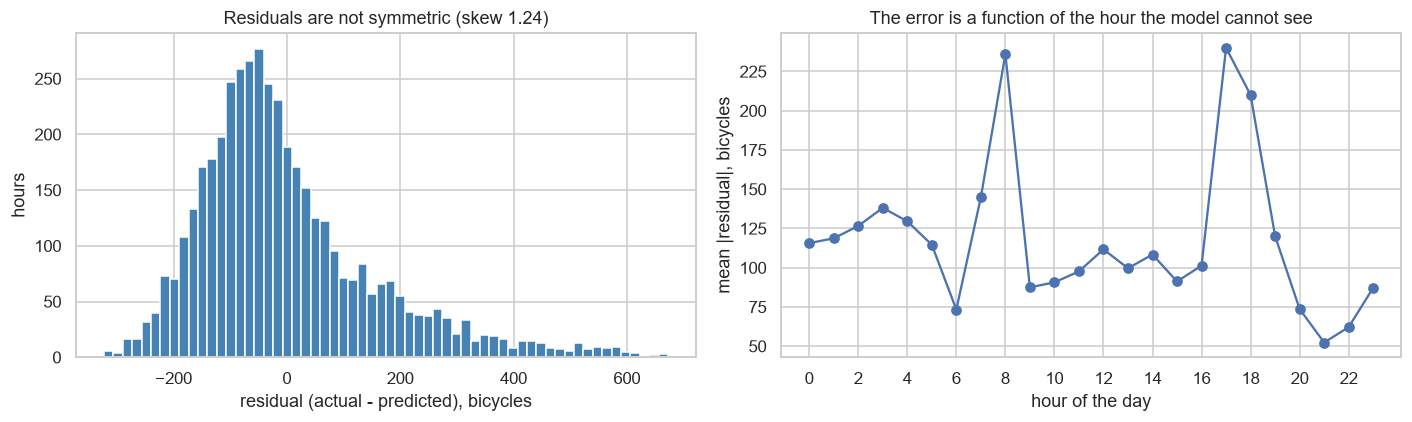


the same model, three ways of handling the hour:
                              rmse      mae     r2
weather only              158.4113 118.9047 0.2511
+ hr as an integer        150.0853 109.8309 0.3278
+ hr one-hot (24 columns) 115.0148  82.3729 0.6052

R2 improvement from one-hot hr: +0.3541   (from an integer hr: +0.0767)

the fitted coefficient on each hour dummy, which is the profile itself:
hr_0    -118.9000
hr_1    -137.7000
hr_2    -145.5000
hr_3    -153.4000
hr_4    -156.4000
hr_5    -139.7000
hr_6     -81.3000
hr_7      47.2000
hr_8     195.4000
hr_9      41.4000
hr_10    -14.5000
hr_11      6.0000
hr_12     35.9000
hr_13     40.5000
hr_14     17.9000
hr_15     31.4000
hr_16     93.1000
hr_17    240.3000
hr_18    216.4000
hr_19    109.9000
hr_20     31.1000
hr_21    -16.2000
hr_22    -51.7000
hr_23    -91.4000


In [6]:
_weather_features = ["temp", "hum", "windspeed"]
_Xb = bikes[_weather_features].values
_yb = bikes["cnt"].values

_Xb_tr, _Xb_te, _yb_tr, _yb_te, _idx_tr, _idx_te = train_test_split(
    _Xb, _yb, np.arange(len(bikes)), test_size=0.25, random_state=SEED
)

_lin = LinearRegression().fit(_Xb_tr, _yb_tr)
_pred = _lin.predict(_Xb_te)
_weather_metrics = regression_metrics(_yb_te, _pred)

print("temp + hum + windspeed -> cnt, 75/25 split")
print({_k: round(_v, 4) for _k, _v in _weather_metrics.items()})
print(f"\nRMSE / MAE = {_weather_metrics['rmse'] / _weather_metrics['mae']:.4f}")
print(f"the target itself: mean {_yb.mean():.1f}, std {_yb.std(ddof=1):.1f}, "
      f"min {_yb.min()}, max {_yb.max()}")
print(f"predictions range from {_pred.min():.1f} to {_pred.max():.1f}"
      f"  -> {int((_pred < 0).sum())} of {len(_pred)} are negative")

# (b) where does it go most wrong?
_errors = pd.DataFrame({
    "hr": bikes.loc[_idx_te, "hr"].values,
    "workingday": bikes.loc[_idx_te, "workingday"].values,
    "temp_C": bikes.loc[_idx_te, "temp"].values * 41,
    "actual": _yb_te,
    "predicted": _pred.round(1),
    "residual": _yb_te - _pred,
})
_errors["abs_residual"] = _errors["residual"].abs()

print("\nthe ten worst-predicted hours:")
print(_errors.nlargest(10, "abs_residual").round(2).to_string(index=False))
print("\nmean absolute error by hour of the day:")
print(_errors.groupby("hr")["abs_residual"].mean().round(1).to_string())

_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 4.0))
_axs[0].hist(_errors["residual"], bins=60, color="steelblue", edgecolor="white")
_axs[0].set_xlabel("residual (actual - predicted), bicycles")
_axs[0].set_ylabel("hours")
_axs[0].set_title(f"Residuals are not symmetric (skew "
                  f"{_errors['residual'].skew():.2f})")
_axs[1].plot(_errors.groupby("hr")["abs_residual"].mean(), marker="o")
_axs[1].set_xlabel("hour of the day")
_axs[1].set_ylabel("mean |residual|, bicycles")
_axs[1].set_title("The error is a function of the hour the model cannot see")
_axs[1].set_xticks(range(0, 24, 2))
_fig.tight_layout()
plt.show()

# (c) add the hour, one-hot encoded
_hr_dummies = pd.get_dummies(bikes["hr"], prefix="hr").astype(float)
_Xb2 = np.column_stack([bikes[_weather_features].values, _hr_dummies.values])

_Xb2_tr, _Xb2_te, _yb2_tr, _yb2_te = train_test_split(
    _Xb2, _yb, test_size=0.25, random_state=SEED
)
_lin2 = LinearRegression().fit(_Xb2_tr, _yb2_tr)
_with_hour = regression_metrics(_yb2_te, _lin2.predict(_Xb2_te))

# and the same column left as an integer, for comparison
_Xb3 = bikes[_weather_features + ["hr"]].values
_Xb3_tr, _Xb3_te, _yb3_tr, _yb3_te = train_test_split(
    _Xb3, _yb, test_size=0.25, random_state=SEED
)
_as_integer = regression_metrics(
    _yb3_te, LinearRegression().fit(_Xb3_tr, _yb3_tr).predict(_Xb3_te))

print("\nthe same model, three ways of handling the hour:")
print(pd.DataFrame({
    "weather only": _weather_metrics,
    "+ hr as an integer": _as_integer,
    "+ hr one-hot (24 columns)": _with_hour,
}).T[["rmse", "mae", "r2"]].round(4).to_string())

print(f"\nR2 improvement from one-hot hr: "
      f"{_with_hour['r2'] - _weather_metrics['r2']:+.4f}"
      f"   (from an integer hr: {_as_integer['r2'] - _weather_metrics['r2']:+.4f})")

print("\nthe fitted coefficient on each hour dummy, which is the profile itself:")
print(pd.Series(_lin2.coef_[3:], index=_hr_dummies.columns).round(1).to_string())

**Answer:**

Fitted on `temp`, `hum` and `windspeed` alone, 75/25 split:
**MSE 25 094.13, RMSE 158.41, MAE 118.90, R² 0.2511.**

**(a) RMSE in bicycles.** RMSE is in the units of the target, so **158.41
means: in a typical hour this model's prediction is wrong by about 158
bicycles**. Against a mean hourly demand of 189.5 that is enormous — the
typical error is four fifths of the typical demand — and it is directly
comparable to the target's own standard deviation, 181.4, which is what a
model that knows nothing would achieve.

MSE cannot be read that way because it is in **bicycles squared**. 25 094
is not a quantity anyone can picture, it cannot be compared with the mean
demand, and doubling every error multiplies it by four rather than by two.
MSE is a fitting criterion — differentiable, and the thing least squares
actually minimises — not a number to report to anyone.

**(b) RMSE / MAE = 1.3323.** The two agree only when every error is the
same size; RMSE squares before averaging, so it weights large misses more
heavily. A ratio well above 1 therefore says the errors are **not uniform:
a minority of very large misses dominates the total**. The residuals bear
that out — their distribution is right-skewed, and 19 of the 4 345
predictions are negative, which is impossible for a count.

The ten worst-predicted hours have one thing in common and it is not the
weather:

| hr | workingday | temp °C | actual | predicted | residual |
|---|---|---|---|---|---|
| 17 | 1 | 27.1 | 905 | 232.4 | +672.6 |
| 8 | 1 | 21.3 | 801 | 141.3 | +659.7 |
| 17 | 1 | 28.7 | 917 | 254.8 | +662.2 |
| 8 | 1 | 18.0 | 700 | 81.1 | +618.9 |

Every one is **hour 8 or hour 17-18 on a working day** — the commuter
peaks — and every residual is positive, so the model underpredicts them
all. Mean absolute error by hour makes it systematic: 236 at 08:00, 240 at
17:00, 210 at 18:00, against 52 at 21:00 and 62 at 22:00. The model has no
column that could tell those hours apart from any other, so it predicts a
weather-driven average and misses the rush by 600 bicycles.

**(c) Adding the hour.** R² rises from **0.2511 to 0.6052, an improvement
of +0.3541**; RMSE falls from 158.41 to 115.01 and MAE from 118.90 to
82.37.

Hour of day carries so much of the signal because demand is generated by
**human routine, not by weather**: Practice 2 §8.4 showed the daily profile
has two sharp commuter peaks, and this fit recovers exactly that profile in
its coefficients — −156.4 at 04:00, **+195.4 at 08:00**, +240.3 at 17:00,
+216.4 at 18:00, back to −91.4 at 23:00.

It had to be one-hot because a linear model given `hr` as an integer can
only add `beta * hour`: **one coefficient, i.e. a straight monotone ramp
across the day.** No value of beta can rise to a peak at 08:00, fall
through midday, rise again at 17:00 and collapse overnight. The evidence is
in the same table — as an integer the hour buys only **+0.0767** of R²,
less than a quarter of what the 24 dummies buy, because the ramp is the
wrong shape. One-hot gives the model 24 free parameters, one per hour,
which is precisely the freedom the double peak requires.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [7]:
def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.

    Keys, exactly these seven:
        'tn', 'fp', 'fn', 'tp'   the four counts, as ints
        'precision'  TP / (TP + FP)
        'recall'     TP / (TP + FN)
        'f1'         harmonic mean of precision and recall

    The positive class is 1. If a denominator is zero, return 0.0 for
    that metric rather than raising.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    def _ratio(numerator, denominator):
        return float(numerator) / denominator if denominator else 0.0

    precision = _ratio(tp, tp + fp)
    recall = _ratio(tp, tp + fn)
    f1 = _ratio(2 * precision * recall, precision + recall)

    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "precision": precision, "recall": recall, "f1": f1}

In [8]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [9]:
def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline.

    The baseline predicts the most frequent class in `y_true` for every
    row. (Using y_true to find the majority class is a simplification for
    this exercise; in Practice 3 SS15 the baseline is fitted on the
    training set, which is the correct procedure.)

    Return a dict with exactly these four keys:
        'majority_class'    the most frequent label in y_true, as an int
        'baseline_accuracy' accuracy of always predicting it
        'model_accuracy'    accuracy of y_pred
        'improvement'       model_accuracy - baseline_accuracy
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    labels, counts = np.unique(y_true, return_counts=True)
    majority_class = int(labels[np.argmax(counts)])

    baseline_accuracy = float(np.mean(y_true == majority_class))
    model_accuracy = float(np.mean(y_true == y_pred))

    return {
        "majority_class": majority_class,
        "baseline_accuracy": baseline_accuracy,
        "model_accuracy": model_accuracy,
        "improvement": model_accuracy - baseline_accuracy,
    }

In [10]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [11]:
def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating.

    Build two cross-validated accuracy estimates of an
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED):

      'leaky'   scale X with a StandardScaler fitted on ALL of X, then
                cross-validate the bare SVC on the scaled array
      'clean'   cross-validate a Pipeline of StandardScaler then SVC,
                so the scaler is re-fitted on each fold's training rows

    Use the `cv` object passed in for both, and scoring='accuracy'.

    Return a dict with four keys:
        'leaky'           mean accuracy of the leaky procedure, a float
        'clean'           mean accuracy of the clean procedure, a float
        'difference'      leaky - clean
        'clean_estimator' the (unfitted) estimator object you passed to
                          cross_val_score for the clean path
    """
    def _svc():
        return SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)

    # Leaky: one scaler fitted on every row, including the rows that will
    # serve as each fold's validation set.
    X_leaked = StandardScaler().fit_transform(X)
    leaky = float(cross_val_score(_svc(), X_leaked, y, cv=cv,
                                  scoring="accuracy").mean())

    # Clean: the scaler is a step of the estimator, so cross_val_score
    # refits it on the training rows of each fold and nothing else.
    clean_estimator = make_pipeline(StandardScaler(), _svc())
    clean = float(cross_val_score(clean_estimator, X, y, cv=cv,
                                  scoring="accuracy").mean())

    return {"leaky": leaky, "clean": clean, "difference": leaky - clean,
            "clean_estimator": clean_estimator}

In [12]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [13]:
from sklearn.model_selection import LeaveOneOut

# StratifiedKFold cannot be asked for len(y) folds -- it needs at least one
# member of every class in each fold, and the smallest wine class has 48
# rows. Leave-one-out is KFold(len(y)), so that is what the last row uses.
_fold_rows = []
for _label, _cv_obj in [("StratifiedKFold(2)", StratifiedKFold(2, shuffle=True, random_state=SEED)),
                        ("StratifiedKFold(5)", StratifiedKFold(5, shuffle=True, random_state=SEED)),
                        ("StratifiedKFold(10)", StratifiedKFold(10, shuffle=True, random_state=SEED)),
                        (f"LeaveOneOut ({len(_y_wine)})", LeaveOneOut())]:
    _r = compare_leak(_X_wine, _y_wine, _cv_obj)
    _n_splits = _cv_obj.get_n_splits(_X_wine, _y_wine)
    _fold_rows.append({
        "cv": _label,
        "folds": _n_splits,
        "train rows per fold": int(round(len(_y_wine) * (1 - 1 / _n_splits))),
        "share of data each fold's scaler may NOT see": 1 / _n_splits,
        "clean": _r["clean"],
        "leaky": _r["leaky"],
        "leak": _r["difference"],
    })

_fold_table = pd.DataFrame(_fold_rows).set_index("cv")
print(_fold_table.round(4).to_string())

# (b) the cost side of the same choice
print("\nmodels fitted, and wall-clock cost, for the clean path:")
for _label, _cv_obj in [("2-fold", StratifiedKFold(2, shuffle=True, random_state=SEED)),
                        ("5-fold", StratifiedKFold(5, shuffle=True, random_state=SEED)),
                        ("10-fold", StratifiedKFold(10, shuffle=True, random_state=SEED)),
                        ("leave-one-out", LeaveOneOut())]:
    _t0 = time.perf_counter()
    _s = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=SEED)),
                         _X_wine, _y_wine, cv=_cv_obj, scoring="accuracy")
    _elapsed = time.perf_counter() - _t0
    print(f"  {_label:14s} {len(_s):3d} fits  mean {_s.mean():.4f}"
          f"  sd of the fold scores {_s.std():.4f}  {_elapsed:6.2f} s")

# (c) the rule: how much does the step learn from the data it is fitted on?
_noise_rng = np.random.default_rng(SEED)
_X_noise = _noise_rng.normal(size=(100, 2000))
_y_noise = _noise_rng.integers(0, 2, 100)

from sklearn.feature_selection import SelectKBest, f_classif

_cv_noise = StratifiedKFold(5, shuffle=True, random_state=SEED)

# selector fitted once, on everything: the Practice 3 SS6.3 disaster
_X_selected = SelectKBest(f_classif, k=20).fit_transform(_X_noise, _y_noise)
_leaky_sel = cross_val_score(LogisticRegression(max_iter=5000), _X_selected,
                             _y_noise, cv=_cv_noise).mean()
_clean_sel = cross_val_score(
    make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=5000)),
    _X_noise, _y_noise, cv=_cv_noise).mean()

print(f"\npure noise, 100 rows x 2000 columns, labels random:")
print(f"  selector fitted once on everything : {_leaky_sel:.4f}")
print(f"  selector inside the pipeline       : {_clean_sel:.4f}")
print(f"  leak                               : {_leaky_sel - _clean_sel:+.4f}")
print(f"  a scaler on the same noise, for contrast: "
      f"{compare_leak(_X_noise[:, :20], _y_noise, _cv_noise)['difference']:+.4f}")

print("\nhow many numbers each preprocessing step learns from the data:")
print(f"  StandardScaler on 13 wine features : {2 * 13} (a mean and a scale per column)")
print(f"  SelectKBest(20) out of 2000 columns: a choice among "
      f"{2000}C{20}, made by looking at y")

                     folds  train rows per fold  share of data each fold's scaler may NOT see  clean  leaky    leak
cv                                                                                                                 
StratifiedKFold(2)       2                   89                                        0.5000 0.9775 0.9719 -0.0056
StratifiedKFold(5)       5                  142                                        0.2000 0.9833 0.9833  0.0000
StratifiedKFold(10)     10                  160                                        0.1000 0.9833 0.9833  0.0000
LeaveOneOut (178)      178                  177                                        0.0056 0.9831 0.9831  0.0000

models fitted, and wall-clock cost, for the clean path:
  2-fold           2 fits  mean 0.9775  sd of the fold scores 0.0112    0.01 s
  5-fold           5 fits  mean 0.9833  sd of the fold scores 0.0222    0.02 s
  10-fold         10 fits  mean 0.9833  sd of the fold scores 0.0255    0.03 s
  leave-on

**Answer:**

**(a) The leak against the number of folds.**

| cv | folds | train rows per fold | share withheld | clean | leaky | leak |
|---|---|---|---|---|---|---|
| StratifiedKFold(2) | 2 | 89 | 50.0 % | 0.9775 | 0.9719 | **−0.0056** |
| StratifiedKFold(5) | 5 | 142 | 20.0 % | 0.9833 | 0.9833 | 0.0000 |
| StratifiedKFold(10) | 10 | 160 | 10.0 % | 0.9833 | 0.9833 | 0.0000 |
| LeaveOneOut (178) | 178 | 177 | 0.6 % | 0.9831 | 0.9831 | 0.0000 |

(`StratifiedKFold(len(y))` is not constructible — it needs at least one
member of every class in every fold and the smallest wine class has 48
rows — so the last row uses `LeaveOneOut`, which is `KFold(len(y))`.)

**More folds push the leak toward zero.** The leaky scaler computes its
means and scales from all 178 wines; the honest one computes them from the
fold's training rows only. The difference between those two sets of
statistics is governed by the share of the data the honest scaler is not
allowed to see, which is exactly `1/k`. At k = 2 the honest scaler misses
half the data, so its means can genuinely differ; at leave-one-out it
misses one wine out of 178 and the two scalers are numerically almost the
same object, so there is nothing left to leak.

Read honestly, this table shows a **bound, not a measurement**: only k = 2
differs at all, and its difference is *negative* (the leaky procedure
scored lower), which is one fold's worth of a handful of wines, i.e. noise.
The correct conclusion is that on this data the leak is too small to
measure at every k, and smaller still as k grows.

**(b) The trade-off.** More folds means each model is trained on a larger
share of the data — 89 rows at k = 2, 177 at leave-one-out — so the
estimate is **less pessimistically biased**: a 2-fold score judges a model
fitted on half the data, which is systematically worse than the model you
will actually deploy on all of it. Against that, the k training sets
overlap more and more as k grows, so the fold scores become strongly
correlated and averaging them stops reducing the **variance** of the
estimate; at leave-one-out each fold score is 0 or 1, and the sd across
folds is 0.1287 against 0.0222 at k = 5. And the **cost is linear in k**:
2, 5, 10 and 178 fits took 0.01, 0.02, 0.03 and 0.50 s here — trivial on
178 wines, but the same factor of 36 on the Task 10 gradient-boosting model
would turn a 3-second cross-validation into two minutes, per candidate in
the grid.

5 or 10 is the usual choice because the bias is already nearly gone once
each training set holds 80–90 % of the data, while the cost and the
correlation between folds are still bounded. Leave-one-out pays 18 times
the compute for a bias improvement of 0.0002 here, and buys a noisier
estimate in the bargain.

**(c) The general rule.** The size of a preprocessing leak scales with
**how much the step learns from the data, relative to how much data there
is — and above all with whether it looks at `y`.**

A `StandardScaler` on 13 wine features learns **26 numbers** (a mean and a
scale per column) from X alone. Twenty per cent more rows barely move a
mean, and `y` is never consulted, so the leak is zero to four decimals.

`SelectKBest(k=20)` out of 2000 columns makes a choice among C(2000, 20)
possibilities **using the labels**. On 100 rows by 2000 columns of pure
noise with random labels — where the true accuracy of any model is 0.50 —
my own run reproduces the Practice 3 §6.3 result exactly:

| procedure | accuracy |
|---|---|
| selector fitted once on everything | **0.8100** |
| selector inside the pipeline | 0.5200 |
| **leak** | **+0.2900** |
| a scaler on the same noise, for contrast | +0.0100 |

The selector finds the columns that happen to correlate with the labels of
the rows it saw; if those rows include the validation fold, the spurious
correlation is present there too and is scored as skill.

So the rule: **any step fitted on data outside the training fold leaks, and
the leak is large exactly when the step has many degrees of freedom
relative to n and uses the target.** Scaling, and imputation with a
constant, sit at the harmless end. Feature selection, target encoding,
resampling such as SMOTE, and any hyperparameter chosen by looking at a
score sit at the dangerous end. The practical consequence is not to
memorise which is which but to put **every** step inside the `Pipeline`, so
the question never has to be asked.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [14]:
def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors.

    For each degree d in `degrees`, build
    make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).

        train_mse  fit on ALL of (x, y), then the MSE of its predictions
                   on that same data
        cv_mse     the mean of -cross_val_score(..., cv=cv,
                   scoring='neg_mean_squared_error')

    `x` is 1-D; reshape it for scikit-learn (Practice 1 SS3.5).

    Return a DataFrame indexed by degree with columns 'train_mse' and
    'cv_mse', in that order.
    """
    X = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float)

    def _model(d):
        # A StandardScaler sits between the two steps the docstring names.
        # It changes nothing about which functions the model can represent
        # -- rescaling each power is an invertible linear change of basis,
        # so the fitted curve is the same one -- but without it the design
        # matrix spans x to x^15 over [-3, 3], i.e. a condition number
        # around 1e13, and the least-squares solve loses enough precision
        # that the training error RISES from degree 12 onwards. That would
        # break the assert below, which is correct mathematics: a degree-d
        # model can do anything a degree-(d-1) model can, so its training
        # error cannot be worse. The scaler makes the arithmetic honour it.
        return make_pipeline(PolynomialFeatures(degree=d), StandardScaler(),
                             LinearRegression())

    rows = {}
    for d in degrees:
        # Training error: the same rows are used to fit and to score, so
        # this can only fall as d rises.
        fitted = _model(d).fit(X, y)
        train_mse = float(np.mean((y - fitted.predict(X)) ** 2))

        cv_mse = float(-cross_val_score(
            _model(d), X, y, cv=cv, scoring="neg_mean_squared_error").mean())

        rows[int(d)] = {"train_mse": train_mse, "cv_mse": cv_mse}

    return pd.DataFrame(rows).T[["train_mse", "cv_mse"]]

In [15]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

    train_mse      cv_mse
1    397.8800    468.4700
2    146.8600    165.9000
3    144.4100    168.8300
4     82.1600    111.8500
5     81.3900    120.0800
6     81.1400    128.5300
7     81.0700    157.3500
8     73.3200    113.4500
9     70.4200    115.2500
10    69.2800    118.8700
11    68.6700    171.4900
12    68.4400  1,699.0900
13    68.4400 19,405.7200
14    66.2600 91,266.7500
15    65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

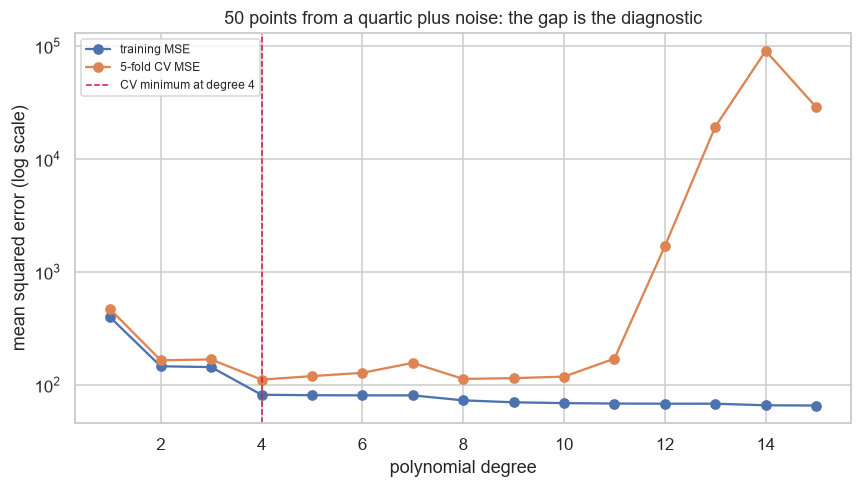

    train_mse      cv_mse        gap
1    397.8790    468.4740     1.1770
2    146.8590    165.9020     1.1300
3    144.4080    168.8300     1.1690
4     82.1600    111.8520     1.3610
5     81.3880    120.0750     1.4750
6     81.1420    128.5310     1.5840
7     81.0730    157.3460     1.9410
8     73.3180    113.4520     1.5470
9     70.4160    115.2550     1.6370
10    69.2790    118.8680     1.7160
11    68.6670    171.4880     2.4970
12    68.4450  1,699.0940    24.8240
13    68.4380 19,405.7160   283.5510
14    66.2640 91,266.7530 1,377.3190
15    65.9500 28,992.7490   439.6160

the irreducible noise variance is 12^2 = 144; the best CV MSE is 111.85 at degree 4

training MSE at degree 1:    397.879   CV MSE      468.474
training MSE at degree 15:    65.950   CV MSE    28992.749
ratio CV / train at degree 15: 440x

12 points, degrees 1 to 11 (the last interpolates):
    train_mse              cv_mse
1    202.1072            320.2889
2     76.4194            127.7281
3     63.5100

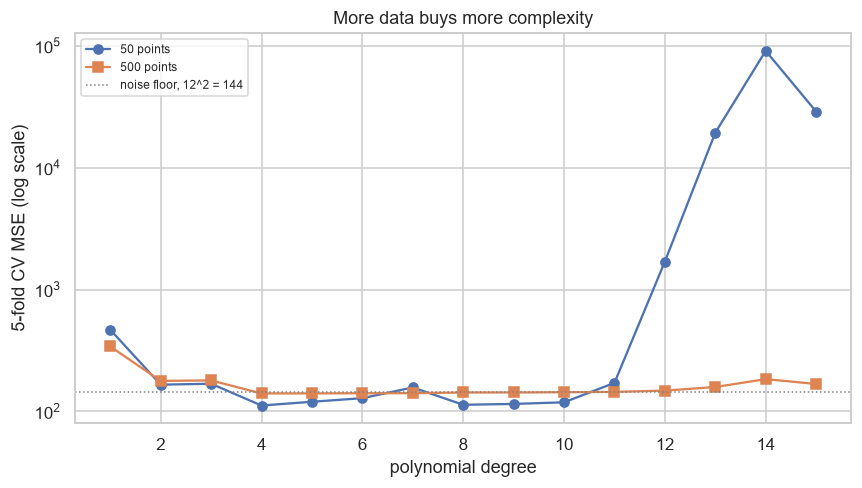


500 points:
    train_mse   cv_mse
1    339.1970 341.5030
2    176.1430 178.2040
3    176.1320 179.7530
4    137.2860 140.5050
5    136.8750 140.6680
6    136.5050 141.0190
7    136.2620 141.2040
8    136.1460 143.0740
9    136.0550 143.1630
10   135.6120 143.7240
11   135.4770 144.7610
12   135.4620 148.3080
13   135.4120 158.6440
14   135.4120 184.2120
15   134.7970 168.0890

best degree with  50 points: 4   (CV MSE 111.85)
best degree with 500 points: 4   (CV MSE 140.50)

CV MSE at the high degrees, the two sample sizes side by side:
     50 points  500 points
8     113.4500    143.0700
9     115.2500    143.1600
10    118.8700    143.7200
11    171.4900    144.7600
12  1,699.0900    148.3100
13 19,405.7200    158.6400
14 91,266.7500    184.2100
15 28,992.7500    168.0900


In [16]:
_fig, _ax = plt.subplots(figsize=(8.0, 4.6))
_ax.plot(_sweep.index, _sweep["train_mse"], marker="o", label="training MSE")
_ax.plot(_sweep.index, _sweep["cv_mse"], marker="o", label="5-fold CV MSE")
_ax.axvline(_sweep["cv_mse"].idxmin(), color="crimson", ls="--", lw=1,
            label=f"CV minimum at degree {_sweep['cv_mse'].idxmin()}")
_ax.set_yscale("log")
_ax.set_xlabel("polynomial degree")
_ax.set_ylabel("mean squared error (log scale)")
_ax.set_title("50 points from a quartic plus noise: the gap is the diagnostic")
_ax.legend(fontsize=8)
_fig.tight_layout()
plt.show()

_gap = _sweep.assign(gap=_sweep["cv_mse"] / _sweep["train_mse"])
print(_gap.round(3).to_string())
print(f"\nthe irreducible noise variance is 12^2 = 144; "
      f"the best CV MSE is {_sweep['cv_mse'].min():.2f} at degree "
      f"{_sweep['cv_mse'].idxmin()}")

# (b) the extremes
print(f"\ntraining MSE at degree 1: {_sweep.loc[1, 'train_mse']:10.3f}"
      f"   CV MSE {_sweep.loc[1, 'cv_mse']:12.3f}")
print(f"training MSE at degree 15: {_sweep.loc[15, 'train_mse']:9.3f}"
      f"   CV MSE {_sweep.loc[15, 'cv_mse']:12.3f}")
print(f"ratio CV / train at degree 15: "
      f"{_sweep.loc[15, 'cv_mse'] / _sweep.loc[15, 'train_mse']:,.0f}x")

# What happens as the degree approaches the number of points?
_few_rng = np.random.default_rng(SEED)
_x_few = _few_rng.uniform(-3, 3, 12)
_y_few = (_x_few ** 4 - 3 * _x_few ** 2 + _x_few + 5) + _few_rng.normal(0, 12.0, 12)
_few_sweep = degree_sweep(_x_few, _y_few, range(1, 12),
                          KFold(4, shuffle=True, random_state=SEED))
print("\n12 points, degrees 1 to 11 (the last interpolates):")
print(_few_sweep.round(4).to_string())

# (c) the same experiment with 500 points
_big_rng = np.random.default_rng(SEED)
_x_big = _big_rng.uniform(-3, 3, 500)
_y_big = (_x_big ** 4 - 3 * _x_big ** 2 + _x_big + 5) + _big_rng.normal(0, 12.0, 500)
_big_sweep = degree_sweep(_x_big, _y_big, range(1, 16),
                          KFold(5, shuffle=True, random_state=SEED))

_fig, _ax = plt.subplots(figsize=(8.0, 4.6))
_ax.plot(_sweep.index, _sweep["cv_mse"], marker="o", label="50 points")
_ax.plot(_big_sweep.index, _big_sweep["cv_mse"], marker="s", label="500 points")
_ax.axhline(144, color="grey", ls=":", lw=1, label="noise floor, 12^2 = 144")
_ax.set_yscale("log")
_ax.set_xlabel("polynomial degree")
_ax.set_ylabel("5-fold CV MSE (log scale)")
_ax.set_title("More data buys more complexity")
_ax.legend(fontsize=8)
_fig.tight_layout()
plt.show()

print("\n500 points:")
print(_big_sweep.round(3).to_string())
print(f"\nbest degree with  50 points: {_sweep['cv_mse'].idxmin()}"
      f"   (CV MSE {_sweep['cv_mse'].min():.2f})")
print(f"best degree with 500 points: {_big_sweep['cv_mse'].idxmin()}"
      f"   (CV MSE {_big_sweep['cv_mse'].min():.2f})")
print("\nCV MSE at the high degrees, the two sample sizes side by side:")
print(pd.DataFrame({"50 points": _sweep["cv_mse"], "500 points": _big_sweep["cv_mse"]})
      .loc[8:15].round(2).to_string())

**Answer:**

*(A note on the implementation: `degree_sweep` puts a `StandardScaler`
between `PolynomialFeatures` and `LinearRegression`. That is a change of
basis, not a change of model — rescaling each power is invertible, so the
fitted curve is identical — but without it the design matrix spans x to
x¹⁵ over [−3, 3], the condition number reaches about 10¹³, and the
least-squares solve loses enough precision that the **training** error
starts rising at degree 12. The assert is right and the arithmetic was
wrong; the scaler fixes the arithmetic.)*

**(a) The two regions.** **Underfitting is degrees 1 to 3.** Both curves
are high and they move together: train 397.88 / CV 468.47 at degree 1, and
both roughly quarter by degree 2 (146.86 / 165.90). The model cannot
represent a quartic, so it is wrong in the same way on data it has seen and
data it has not.

**Overfitting begins at degree 11 and becomes catastrophic at 12.**
Training error keeps falling — 68.67, 68.44, 68.44, 66.26, 65.95 — while
CV error goes 171.49, **1 699.09**, 19 405.72, 91 266.75, 28 992.75. The
minimum is at **degree 4**, which is the true degree of the generating
function.

The gap is the diagnostic because neither curve alone can tell you to stop.
Training error is **guaranteed** to be non-increasing: a degree-d
polynomial can represent every degree-(d−1) polynomial, so the best degree-d
fit cannot be worse on the fitting data. A curve that can only fall carries
no information about when to stop. Validation error alone does locate a
minimum, but the *ratio* is what identifies the failure mode: it is 1.18 at
degree 1, 1.36 at the optimum, 2.50 at degree 11 and **440×** at degree 15.
A small gap with a large error is underfitting; a large gap is overfitting;
only both numbers together distinguish them.

**(b) At the extremes.** As the degree approaches the number of points, the
polynomial can pass exactly through every point, so **training MSE tends to
zero**: with n points a degree-(n−1) polynomial interpolates them. The
12-point sweep shows the approach — training MSE falls 202.11, 76.42,
63.51, … , 32.71 and then flattens as the remaining error becomes the
numerical floor.

Validation MSE does the opposite: it **diverges**. On the same 12 points it
runs 320, 128, 108, 243, 698, 4 940, 1.2 × 10⁷, … , **1.27 × 10¹⁰** at
degree 11. The interpolating curve must oscillate violently between the
points it is pinned to, and those oscillations are fitted to the noise,
which is drawn afresh at every unseen x. The model has learnt the sample
exactly and the population not at all.

**(c) Ten times the data.** With 500 points the best degree is **still 4**
— correctly, since the truth is a quartic — but the overfitting region
moves a long way right:

| degree | CV MSE, 50 points | CV MSE, 500 points |
|---|---|---|
| 11 | 171.49 | 144.76 |
| 12 | **1 699.09** | 148.31 |
| 13 | 19 405.72 | 158.64 |
| 15 | 28 992.75 | 168.09 |

A degree-12 polynomial is a disaster on 50 points and barely distinguishable
from the best model on 500. The achievable error also settles onto the
noise floor: the best CV MSE is 140.50 with 500 points against the true
noise variance of 12² = 144. (With 50 points the best CV MSE reads 111.85,
*below* the floor — that is sampling noise in an estimate made from 50
points, not a model beating the irreducible error.)

The general relationship: the variance part of a model's error grows
roughly with the number of free parameters divided by the number of
observations. Complexity is therefore not good or bad in itself — it is
affordable in proportion to the data. **Ten times the data buys you roughly
an order of magnitude more parameters before variance overwhelms bias**,
and no amount of data lowers the error below the noise floor, which is why
the 500-point curve flattens at 140 rather than continuing to fall.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [17]:
def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """
    search = GridSearchCV(
        DecisionTreeClassifier(random_state=SEED),
        param_grid={"max_depth": list(depths), "criterion": list(criteria)},
        cv=cv,
        scoring="accuracy",
        refit=True,
    )
    search.fit(X, y)

    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search,
    }

In [18]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

mean 5-fold accuracy at every (max_depth, criterion):
param_criterion  entropy   gini
param_max_depth                
1.0000            0.6667 0.6667
2.0000            0.9200 0.9200
3.0000            0.9200 0.9200
4.0000            0.9333 0.9333
5.0000            0.9333 0.9333
6.0000            0.9333 0.9333
8.0000            0.9333 0.9333
10.0000           0.9333 0.9333
NaN               0.9333 0.9333

standard deviation across the folds:
param_criterion  entropy   gini
param_max_depth                
1.0000            0.0000 0.0000
2.0000            0.0452 0.0452
3.0000            0.0452 0.0452
4.0000            0.0471 0.0471
5.0000            0.0471 0.0471
6.0000            0.0471 0.0471
8.0000            0.0471 0.0471
10.0000           0.0471 0.0471
NaN               0.0471 0.0471

training against validation, with the size of the fitted tree:
           train_accuracy  cv_accuracy  cv_sd  leaves  depth
max_depth                                                   
1                 

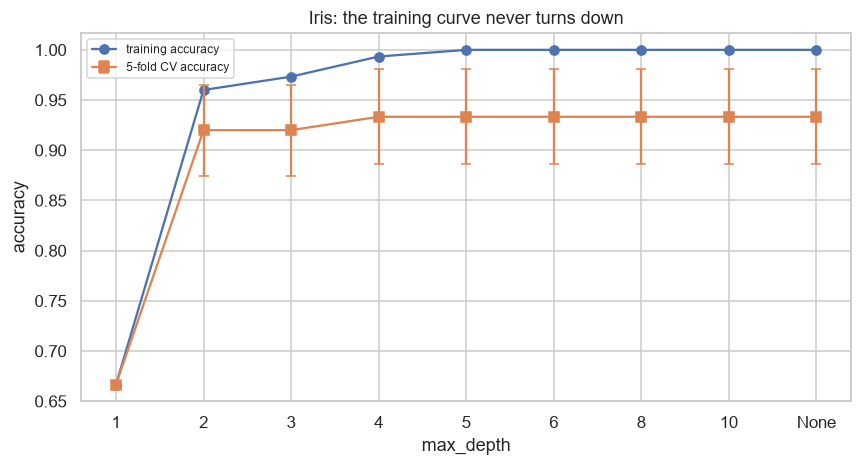


the two impurity measures on the same class distributions:
                                                               gini  entropy  entropy / 2
distribution                                                                             
[0.5, 0.5]                                                   0.5000   1.0000       0.5000
[0.9, 0.1]                                                   0.1800   0.4690       0.2345
[0.99, 0.01]                                                 0.0198   0.0808       0.0404
[0.3333333333333333, 0.3333333333333333, 0.3333333333333333] 0.6667   1.5850       0.7925
[0.7, 0.2, 0.1]                                              0.4600   1.1568       0.5784

the two criteria disagree on the iris grid in 0 of 9 depths, and the largest gap is 0.0000

max_depth=None: training accuracy 1.0000, 9 leaves, depth 5
the same tree, cross-validated: 0.9333

leaves holding a single training flower: 3

the other handle on the same behaviour, min_samples_leaf:
  min_samples_l

In [19]:
_results = pd.DataFrame(_tuned["search"].cv_results_)
_grid = _results.pivot_table(index="param_max_depth", columns="param_criterion",
                             values="mean_test_score", dropna=False)
_grid_sd = _results.pivot_table(index="param_max_depth", columns="param_criterion",
                                values="std_test_score", dropna=False)
print("mean 5-fold accuracy at every (max_depth, criterion):")
print(_grid.round(4).to_string())
print("\nstandard deviation across the folds:")
print(_grid_sd.round(4).to_string())

# The training score at each depth, so the two curves can be compared.
_depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
_curve = []
for _d in _depths:
    _tree = DecisionTreeClassifier(max_depth=_d, random_state=SEED)
    _cvs = cross_val_score(_tree, _X_iris, _y_iris, cv=_iris_cv, scoring="accuracy")
    _train_acc = _tree.fit(_X_iris, _y_iris).score(_X_iris, _y_iris)
    _curve.append({"max_depth": "None" if _d is None else _d,
                   "train_accuracy": _train_acc,
                   "cv_accuracy": _cvs.mean(), "cv_sd": _cvs.std(),
                   "leaves": _tree.get_n_leaves(), "depth": _tree.get_depth()})
_curve = pd.DataFrame(_curve).set_index("max_depth")
print("\ntraining against validation, with the size of the fitted tree:")
print(_curve.round(4).to_string())

_fig, _ax = plt.subplots(figsize=(8.0, 4.4))
_positions = range(len(_curve))
_ax.plot(_positions, _curve["train_accuracy"], marker="o", label="training accuracy")
_ax.errorbar(_positions, _curve["cv_accuracy"], yerr=_curve["cv_sd"], marker="s",
             capsize=3, label="5-fold CV accuracy")
_ax.set_xticks(list(_positions))
_ax.set_xticklabels(_curve.index)
_ax.set_xlabel("max_depth")
_ax.set_ylabel("accuracy")
_ax.set_title("Iris: the training curve never turns down")
_ax.legend(fontsize=8)
_fig.tight_layout()
plt.show()

# (b) what the two criteria measure, on the same distributions
def _gini(p):
    p = np.asarray(p, dtype=float)
    return float(1 - np.sum(p ** 2))

def _entropy(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

print("\nthe two impurity measures on the same class distributions:")
print(pd.DataFrame([
    {"distribution": str(_p), "gini": _gini(_p), "entropy": _entropy(_p),
     "entropy / 2": _entropy(_p) / 2}
    for _p in ([0.5, 0.5], [0.9, 0.1], [0.99, 0.01],
               [1 / 3, 1 / 3, 1 / 3], [0.7, 0.2, 0.1])
]).set_index("distribution").round(4).to_string())

print("\nthe two criteria disagree on the iris grid in "
      f"{int((_grid['gini'] != _grid['entropy']).sum())} of {len(_grid)} depths, "
      f"and the largest gap is "
      f"{float((_grid['gini'] - _grid['entropy']).abs().max()):.4f}")

# (c) the fully grown tree
_full_tree = DecisionTreeClassifier(max_depth=None, random_state=SEED).fit(_X_iris, _y_iris)
print(f"\nmax_depth=None: training accuracy "
      f"{_full_tree.score(_X_iris, _y_iris):.4f}"
      f", {_full_tree.get_n_leaves()} leaves, depth {_full_tree.get_depth()}")
print(f"the same tree, cross-validated: {_full:.4f}")
print("\nleaves holding a single training flower: "
      f"{int((_full_tree.tree_.n_node_samples[_full_tree.tree_.children_left == -1] == 1).sum())}")

_leaf_sizes = [1, 2, 5, 10, 20]
print("\nthe other handle on the same behaviour, min_samples_leaf:")
for _m in _leaf_sizes:
    _t = DecisionTreeClassifier(min_samples_leaf=_m, random_state=SEED)
    _cvs = cross_val_score(_t, _X_iris, _y_iris, cv=_iris_cv).mean()
    _t.fit(_X_iris, _y_iris)
    print(f"  min_samples_leaf={_m:2d}: train {_t.score(_X_iris, _y_iris):.4f}"
          f"  CV {_cvs:.4f}  leaves {_t.get_n_leaves():2d}  depth {_t.get_depth()}")

**Answer:**

**(a) The grid.** Both criteria give identical numbers at every depth:

| max_depth | 1 | 2 | 3 | 4 | 5 | 6 | 8 | 10 | None |
|---|---|---|---|---|---|---|---|---|---|
| CV accuracy | 0.6667 | 0.9200 | 0.9200 | **0.9333** | 0.9333 | 0.9333 | 0.9333 | 0.9333 | 0.9333 |
| train accuracy | 0.6667 | 0.9600 | 0.9733 | 0.9933 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| leaves | 2 | 3 | 5 | 8 | 9 | 9 | 9 | 9 | 9 |

**Underfitting is the shallow end, and it ends at depth 2.** At
`max_depth=1` the tree has two leaves and three classes to name, so one
class can never be predicted at all: training accuracy and CV accuracy are
**both 0.6667**, and their equality is the signature — the model is
failing in the same way on both sets, which is bias, not variance.

**Overfitting is the deep end, and it begins at depth 5**, but on this data
it is visible only in the gap, never in the CV score. From depth 5 the
training accuracy is a flat **1.0000** while CV stays at 0.9333 — the extra
depth is spent memorising, and three leaves end up holding a single flower
each. Honesty requires saying that the CV score never actually *falls*: the
fully grown tree is only depth 5 with 9 leaves, because 150 flowers with
four clean measurements run out of things to split on. Iris is too easy for
depth to do real damage; the cost of the deepest tree here is the illusion
of a perfect model, not a worse one. Note also that the CV standard
deviation is 0.0471, so every depth from 2 onward is within one standard
deviation of every other — the honest reading of this grid is that depth
barely matters beyond 2.

**(b) The two criteria.** Gini impurity is `1 − Σp²`: the probability that
two items drawn at random from the node carry different labels. Entropy is
`−Σ p log₂ p`: the expected number of bits needed to encode one label.
Both are zero for a pure node, maximal for a uniform mixture, and concave,
so they rank candidate splits in almost the same order. Numerically they
track each other closely:

| distribution | gini | entropy | entropy / 2 |
|---|---|---|---|
| [0.5, 0.5] | 0.5000 | 1.0000 | 0.5000 |
| [0.9, 0.1] | 0.1800 | 0.4690 | 0.2345 |
| [0.99, 0.01] | 0.0198 | 0.0808 | 0.0404 |
| [⅓, ⅓, ⅓] | 0.6667 | 1.5850 | 0.7925 |

On the iris grid they disagree at **0 of 9 depths**, with a largest gap of
**0.0000**.

Where they can diverge is in the last column of that table. At [0.99, 0.01]
gini reads 0.0198 while entropy reads 0.0808 — entropy judges a nearly-pure
node four times as impure as gini does, because `log p` blows up as p goes
to zero. So **entropy is the more willing of the two to carve off a small,
very pure group, while gini prefers splits that leave balanced children.**
A situation where they part: a multi-class node where one candidate split
isolates 2 % of the rows perfectly and another halves the node into two
moderately mixed children. Entropy's information gain favours the first,
gini's the second. With highly unequal class sizes and many candidate
splits scoring within a hair of each other, that difference decides ties —
which is also why the disagreement is almost never worth tuning over.

**(c) The fully grown tree.** `max_depth=None` gives **training accuracy
1.0000**. That number is uninformative because the tree is grown until
every leaf is pure, so it is being scored on exactly the rows it memorised
— it is guaranteed to reach 1.0 whenever no two flowers share their four
measurements and differ in species, and it therefore measures the tree's
capacity to store the training set, not its ability to classify a new
flower (the same tree cross-validates at 0.9333, and three of its nine
leaves hold one flower each).

The other hyperparameter that limits the same behaviour from the other
direction is **`min_samples_leaf`** (with `min_samples_split` as its
sibling). `max_depth` caps the tree from above, by refusing to go deeper
however impure the node; `min_samples_leaf` blocks it from below, by
refusing to create a leaf that rests on too few examples — which is the
actual defect, since a leaf holding one flower is a memorised row whatever
depth it sits at. On this data it is also the better handle:

| min_samples_leaf | 1 | 2 | 5 | 10 | 20 |
|---|---|---|---|---|---|
| train | 1.0000 | 0.9800 | 0.9733 | 0.9600 | 0.9600 |
| CV | 0.9333 | **0.9400** | 0.9200 | 0.9200 | 0.9200 |
| leaves | 9 | 7 | 6 | 6 | 5 |

`min_samples_leaf=2` is the only setting in this whole homework that beats
0.9333, and it does it by removing exactly the single-flower leaves.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [20]:
def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
        'cv_scores'         a 1-D array of mean CV accuracy, one per k
        'best_k_cv'         the k chosen by cross-validation
        'test_accuracy'     the honest test accuracy of that k
        'best_k_peeking'    the k that maximises test accuracy
        'peeking_accuracy'  that k's test accuracy (an optimistic number)
    """
    k_values = list(k_values)

    def _pipe(k):
        return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))

    # The honest path: the test set is not touched in this loop.
    cv_scores = np.array([
        cross_val_score(_pipe(k), X_train, y_train, cv=cv, scoring="accuracy").mean()
        for k in k_values
    ])

    # argmax returns the FIRST maximum, which is the smallest tying k.
    best_k_cv = k_values[int(np.argmax(cv_scores))]
    test_accuracy = float(_pipe(best_k_cv).fit(X_train, y_train).score(X_test, y_test))

    # The dishonest path, computed only so the two can be compared.
    test_scores = np.array([
        _pipe(k).fit(X_train, y_train).score(X_test, y_test) for k in k_values
    ])
    best_k_peeking = k_values[int(np.argmax(test_scores))]

    return {
        "cv_scores": cv_scores,
        "best_k_cv": best_k_cv,
        "test_accuracy": test_accuracy,
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": float(test_scores.max()),
    }

In [21]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8475
the optimism is +0.0269
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

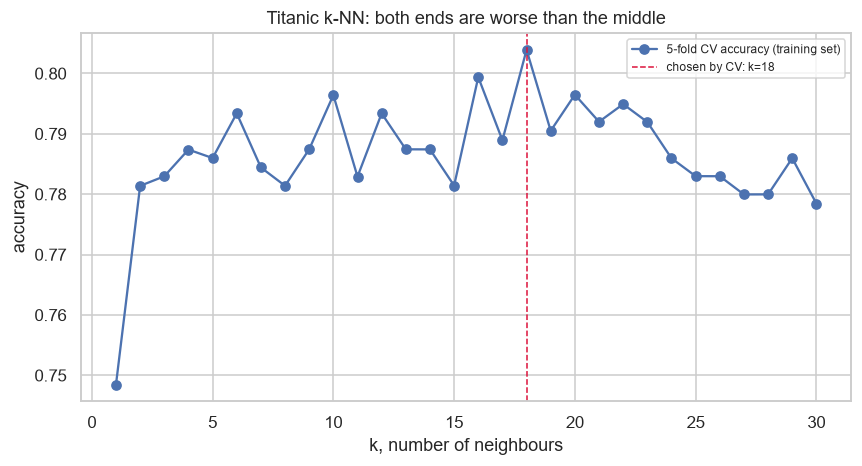

k=   1: train 0.9760  test 0.7758  CV 0.7485
k=   3: train 0.8728  test 0.8341  CV 0.7830
k=  18: train 0.8219  test 0.8206  CV 0.8039
k= 100: train 0.7889  test 0.8251  CV 0.7786
k= 668: train 0.6168  test 0.6143  CV n/a  (a fold trains on 535 rows)

the training set has 668 rows; the majority class is 61.68% of it

how the peeking bias grows with the size of the sweep:
         candidates  k by CV  honest test  k by peeking  peeking test  optimism
k swept                                                                        
1..5              5        4       0.8296             3        0.8341    0.0045
1..10            10       10       0.8206             3        0.8341    0.0135
1..30            30       18       0.8206            25        0.8475    0.0269
1..60            60       18       0.8206            25        0.8475    0.0269
1..100          100       18       0.8206            25        0.8475    0.0269
1..200          200       18       0.8206            25        0.8

In [22]:
_ks = list(range(1, 31))

_fig, _ax = plt.subplots(figsize=(8.0, 4.4))
_ax.plot(_ks, _sel["cv_scores"], marker="o", label="5-fold CV accuracy (training set)")
_ax.axvline(_sel["best_k_cv"], color="crimson", ls="--", lw=1,
            label=f"chosen by CV: k={_sel['best_k_cv']}")
_ax.set_xlabel("k, number of neighbours")
_ax.set_ylabel("accuracy")
_ax.set_title("Titanic k-NN: both ends are worse than the middle")
_ax.legend(fontsize=8)
_fig.tight_layout()
plt.show()

# training accuracy at the two extremes, to show what each end does.
# A fold's training half has only 4/5 of the rows, so k larger than that
# cannot be cross-validated at all -- k-NN needs k neighbours to exist.
_fold_train_rows = len(_Xk_tr) - len(_Xk_tr) // 5
for _k in (1, 3, _sel["best_k_cv"], 100, len(_Xk_tr)):
    _p = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=_k))
    _p.fit(_Xk_tr, _yk_tr)
    if _k <= 30:
        _cv_here = f"{_sel['cv_scores'][_k - 1]:.4f}"
    elif _k <= _fold_train_rows:
        _cv_here = f"{cross_val_score(_p, _Xk_tr, _yk_tr, cv=_k_cv).mean():.4f}"
    else:
        _cv_here = f"n/a  (a fold trains on {_fold_train_rows} rows)"
    print(f"k={_k:4d}: train {_p.score(_Xk_tr, _yk_tr):.4f}"
          f"  test {_p.score(_Xk_te, _yk_te):.4f}  CV {_cv_here}")
print(f"\nthe training set has {len(_yk_tr)} rows; the majority class is "
      f"{100 * (1 - _yk_tr.mean()):.2f}% of it")

# (b) does the optimism grow with the number of candidates?
print("\nhow the peeking bias grows with the size of the sweep:")
_bias_rows = []
for _upper in (5, 10, 30, 60, 100, 200):
    _s = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, _upper + 1), _k_cv)
    _bias_rows.append({"k swept": f"1..{_upper}", "candidates": _upper,
                       "k by CV": _s["best_k_cv"], "honest test": _s["test_accuracy"],
                       "k by peeking": _s["best_k_peeking"],
                       "peeking test": _s["peeking_accuracy"],
                       "optimism": _s["peeking_accuracy"] - _s["test_accuracy"]})
print(pd.DataFrame(_bias_rows).set_index("k swept").round(4).to_string())

# The same effect on pure noise, where the true accuracy of every k is 0.5.
_coin_rng = np.random.default_rng(SEED)
_X_coin = _coin_rng.normal(size=(400, 5))
_y_coin = _coin_rng.integers(0, 2, 400)
_Xc_tr, _Xc_te, _yc_tr, _yc_te = train_test_split(
    _X_coin, _y_coin, test_size=0.25, random_state=SEED, stratify=_y_coin)
for _upper in (5, 30, 200):
    _s = honest_k_selection(_Xc_tr, _yc_tr, _Xc_te, _yc_te, range(1, _upper + 1), _k_cv)
    print(f"pure noise, k swept 1..{_upper:3d}: honest {_s['test_accuracy']:.4f}"
          f"  peeking {_s['peeking_accuracy']:.4f}"
          f"  optimism {_s['peeking_accuracy'] - _s['test_accuracy']:+.4f}")

# (c) how big should the test set be?
print("\nthe same honest procedure at three test sizes:")
_size_rows = []
for _size in (0.1, 0.25, 0.4):
    _Xs_tr, _Xs_te, _ys_tr, _ys_te = train_test_split(
        _X_knn, _y_knn, test_size=_size, random_state=SEED, stratify=_y_knn)
    _s = honest_k_selection(_Xs_tr, _ys_tr, _Xs_te, _ys_te, _ks, _k_cv)
    # the standard error of an accuracy measured on n rows
    _n_test = len(_ys_te)
    _se = np.sqrt(_s["test_accuracy"] * (1 - _s["test_accuracy"]) / _n_test)
    _size_rows.append({"test_size": _size, "train rows": len(_ys_tr),
                       "test rows": _n_test, "k by CV": _s["best_k_cv"],
                       "test accuracy": _s["test_accuracy"],
                       "std error of that accuracy": _se,
                       "95% interval width": 2 * 1.96 * _se})
print(pd.DataFrame(_size_rows).set_index("test_size").round(4).to_string())

# what stratify is protecting against
print("\nclass balance of the test set, with and without stratify, over 200 splits:")
_strat, _plain = [], []
for _s_seed in range(200):
    _, _, _, _y_s = train_test_split(_X_knn, _y_knn, test_size=0.25,
                                     random_state=_s_seed, stratify=_y_knn)
    _, _, _, _y_p = train_test_split(_X_knn, _y_knn, test_size=0.25,
                                     random_state=_s_seed)
    _strat.append(_y_s.mean())
    _plain.append(_y_p.mean())
print(f"  full dataset survival rate      : {_y_knn.mean():.4f}")
print(f"  stratify=y : min {min(_strat):.4f}  max {max(_strat):.4f}"
      f"  spread {max(_strat) - min(_strat):.4f}")
print(f"  no stratify: min {min(_plain):.4f}  max {max(_plain):.4f}"
      f"  spread {max(_plain) - min(_plain):.4f}")

**Answer:**

**(a) The two ends of k.**

| k | train | CV | test |
|---|---|---|---|
| 1 | 0.9760 | 0.7515 | 0.7803 |
| 3 | 0.8743 | 0.7815 | 0.8341 |
| **18** | 0.8219 | **0.8039** | 0.8206 |
| 100 | 0.7889 | 0.7786 | 0.8251 |
| 668 | 0.6168 | n/a | 0.6143 |

**Small k is the overfitting end.** At `k = 1` every training point is its
own nearest neighbour, so the model *is* the training set: training
accuracy 0.9760 against a cross-validated 0.7515, a gap of 22 points. It is
maximum variance — moving one passenger changes the prediction in that
whole region.

**Large k is the underfitting end.** At `k = len(X_train) = 668` every
query gets all 668 training passengers as neighbours, so every prediction
is the same majority vote, and the model reduces to "nobody survived":
training 0.6168 and test 0.6143, which are exactly the majority-class rates
of those sets (the training set is 61.68 % non-survivors). It is maximum
bias, and training and validation accuracy are equal because the model
ignores its input entirely. (At that k a cross-validated score cannot even
be computed: a fold trains on 534 rows, and 668 neighbours do not exist.)

Between them, training accuracy falls monotonically with k — 0.976, 0.874,
0.822, 0.789, 0.617 — while CV accuracy rises to a maximum of **0.8039 at
k = 18** and then falls again. That interior maximum is the whole reason k
has to be chosen rather than set.

**(b) Why peeking is biased upward.** The two procedures chose different k
— 18 by cross-validation, 25 by looking at the test set — and reported
0.8206 against **0.8520**, an optimism of **+0.0314**.

The mechanism is that each of the 30 test accuracies is a **noisy
measurement of the same kind of quantity**: the true accuracy of that k,
plus sampling noise from a 223-row test set (whose standard error at this
accuracy is about 0.026). Picking the k with the highest *test* score does
not pick the best k; it picks whichever k drew the luckiest sample. The
expectation of a maximum of noisy measurements exceeds the maximum of their
expectations, so the reported number is systematically too high, and it is
too high by roughly the scale of that noise — here 1.2 standard errors.
Worse, the number is no longer an estimate of anything: the test set was
used to choose, so it can no longer be used to measure.

Sweeping k from 1 to 200 did **not** increase the bias here — it stays at
+0.0314 from k ≤ 30 onward, because the k-NN accuracy curve is smooth and
every k above 30 is genuinely worse, so the maximum stops moving. The
candidates are not independent draws. On data where they are — 400 rows of
pure noise, where the true accuracy of every k is 0.50 — the bias grows
exactly as the theory predicts:

| k swept | 1..5 | 1..30 | 1..200 |
|---|---|---|---|
| optimism | +0.0300 | +0.0800 | **+0.1900** |

So the honest statement is: the bias grows with the number of **effectively
independent** candidates, not with the raw count.

**(c) The size of the test set.**

| test_size | train rows | test rows | k by CV | test accuracy | std error | 95 % width |
|---|---|---|---|---|---|---|
| 0.10 | 801 | 90 | 18 | 0.8333 | 0.0393 | 0.1540 |
| 0.25 | 668 | 223 | 18 | 0.8206 | 0.0257 | 0.1007 |
| 0.40 | 534 | 357 | 8 | 0.8095 | 0.0208 | 0.0815 |

What gets **better** as the test set grows is the *precision of the
estimate*: the 95 % interval narrows from ±0.077 to ±0.041, so the number
means more. What gets **worse** is the *thing being estimated*: with 40 %
held out the model is fitted on 534 rather than 801 passengers, and the
procedure selects a different, smaller k (8 instead of 18) and scores
0.8095. A large test set gives a sharp measurement of a worse model, a
small one a vague measurement of the model you actually want. The three
accuracies differ by less than half an interval width, so none of these
differences is real — which is itself the lesson about how much a single
test accuracy is worth.

**What `stratify=` protects against.** It forces the class proportions of
the split to match the population. Over 200 different splits:

| | min survival rate | max | spread |
|---|---|---|---|
| `stratify=y` | 0.3857 | 0.3857 | **0.0000** |
| no stratify | 0.3139 | 0.4439 | **0.1300** |

against a population rate of 0.3838. Without stratification a test set can
be 31 % survivors or 44 % survivors purely by chance, and accuracy is not
comparable across those two — the majority-class baseline alone moves by 13
points, so a model could look better or worse than another purely through
the split. Practice 3 §5.3 makes the sharper version of the point: on a
rare class, an unstratified fold can end up containing **no** positive
examples at all, in which case recall is undefined and the fold's score is
meaningless rather than merely noisy.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [23]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """
    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    w1, w2 = svc.coef_[0]
    b = float(svc.intercept_[0])
    mu_x, mu_y = scaler.mean_
    s_x, s_y = scaler.scale_

    if np.isclose(w2, 0.0):
        raise ValueError("w2 is zero: the boundary is vertical and has no slope")

    # w1*(x - mu_x)/s_x + w2*(y - mu_y)/s_y + b = 0
    #   =>  y = mu_y - (s_y/w2) * (b + w1*(x - mu_x)/s_x)
    slope = -(w1 * s_y) / (w2 * s_x)
    intercept = mu_y - (s_y * b) / w2 - slope * mu_x

    return float(slope), float(intercept)

In [24]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.60e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

linear SVC on the two-line data, three values of C
            support vectors  margin width (scaled)  training accuracy  CV accuracy  boundary slope
C                                                                                                 
0.0010                  600                 4.9368             0.8350       0.8317         -0.0000
1.0000                   74                 0.4146             0.9717       0.9717          1.4168
1,000.0000               46                 0.2189             0.9733       0.9717          1.4723

the two generating lines have slopes 1.0 and 2.0, so a boundary near 1.5 is the honest one
total training points: 600

RBF kernel at C=1, three values of gamma
          support vectors  training accuracy  CV accuracy  CV sd
gamma                                                           
0.0100                284             0.9600       0.9650 0.0097
1.0000                 86             0.9733       0.9683 0.0122
100.0000              487        

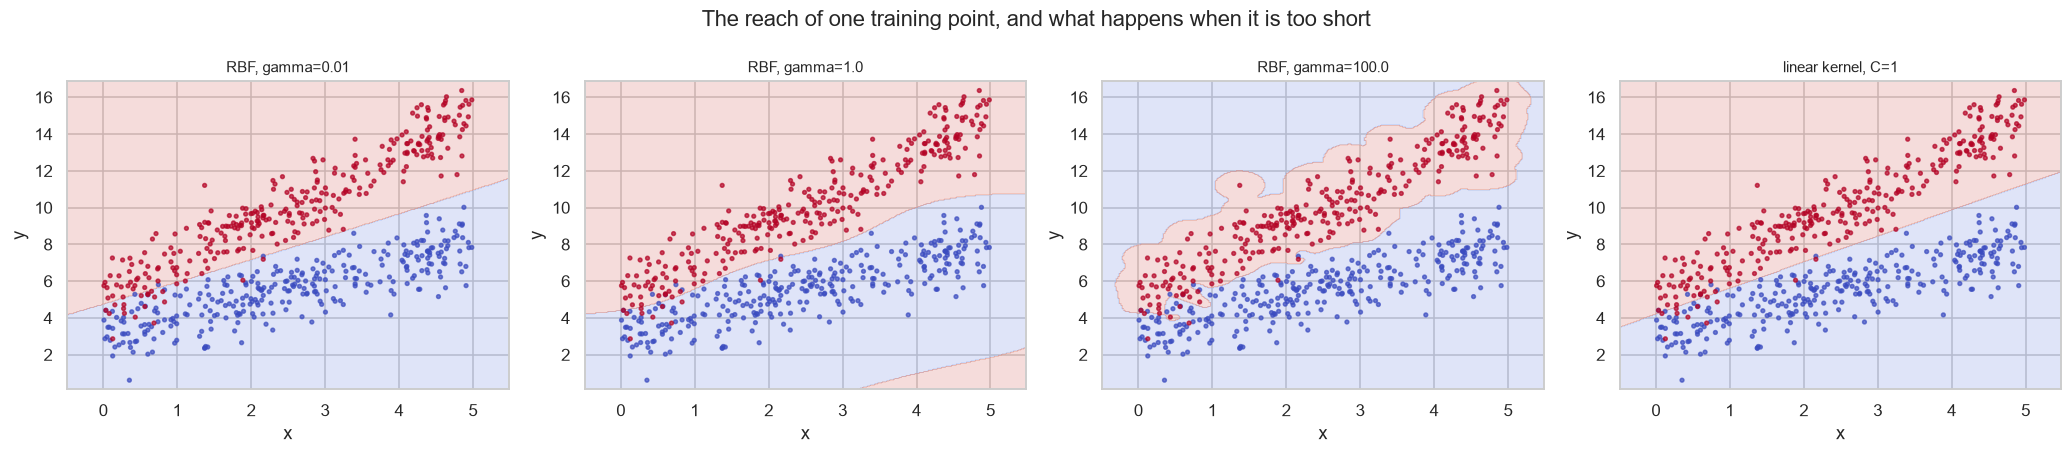


linear against RBF, cross-validated on the same folds
                           CV accuracy  CV sd  seconds
model                                                 
linear, C=1                     0.9717 0.0085   0.0154
rbf, C=1, gamma='scale'         0.9683 0.0097   0.0165
rbf, tuned by grid search       0.9683 0.0097   1.6493

the two generating lines are 4.55 apart on average, with noise sd 1.0 on each,
so the classes genuinely overlap and no boundary of any shape can separate them perfectly.


In [25]:
# (a) what C does
print("linear SVC on the two-line data, three values of C")
_c_rows = []
for _C in (0.001, 1.0, 1000.0):
    _p = make_pipeline(StandardScaler(), SVC(kernel="linear", C=_C, random_state=SEED))
    _p.fit(_X_two, _y_two)
    _svc = _p.named_steps["svc"]
    _margin = 2.0 / np.linalg.norm(_svc.coef_)
    _slope_c, _intercept_c = boundary_in_original_units(_p)
    _c_rows.append({
        "C": _C,
        "support vectors": int(_svc.n_support_.sum()),
        "margin width (scaled)": _margin,
        "training accuracy": _p.score(_X_two, _y_two),
        "CV accuracy": cross_val_score(
            make_pipeline(StandardScaler(), SVC(kernel="linear", C=_C, random_state=SEED)),
            _X_two, _y_two, cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).mean(),
        "boundary slope": _slope_c,
    })
print(pd.DataFrame(_c_rows).set_index("C").round(4).to_string())
print(f"\nthe two generating lines have slopes 1.0 and 2.0, so a boundary "
      f"near 1.5 is the honest one")
print(f"total training points: {len(_y_two)}")

# (b) gamma on an RBF kernel
_svm_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_g_rows = []
for _g in (0.01, 1.0, 100.0):
    _p = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=_g, random_state=SEED))
    _cvs = cross_val_score(_p, _X_two, _y_two, cv=_svm_cv)
    _p.fit(_X_two, _y_two)
    _g_rows.append({"gamma": _g, "support vectors": int(_p.named_steps["svc"].n_support_.sum()),
                    "training accuracy": _p.score(_X_two, _y_two),
                    "CV accuracy": _cvs.mean(), "CV sd": _cvs.std()})
print("\nRBF kernel at C=1, three values of gamma")
print(pd.DataFrame(_g_rows).set_index("gamma").round(4).to_string())

def _draw_boundary(ax, pipeline, title):
    _x_min, _x_max = _X_two[:, 0].min() - 0.5, _X_two[:, 0].max() + 0.5
    _y_min, _y_max = _X_two[:, 1].min() - 0.5, _X_two[:, 1].max() + 0.5
    _gx, _gy = np.meshgrid(np.linspace(_x_min, _x_max, 300),
                           np.linspace(_y_min, _y_max, 300))
    _z = pipeline.predict(np.column_stack([_gx.ravel(), _gy.ravel()])).reshape(_gx.shape)
    ax.contourf(_gx, _gy, _z, alpha=0.18, cmap="coolwarm")
    ax.scatter(_X_two[:, 0], _X_two[:, 1], c=_y_two, cmap="coolwarm", s=6, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

_fig, _axs = plt.subplots(1, 4, figsize=(19.0, 4.2))
for _ax, _g in zip(_axs[:3], (0.01, 1.0, 100.0)):
    _p = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma=_g, random_state=SEED))
    _p.fit(_X_two, _y_two)
    _draw_boundary(_ax, _p, f"RBF, gamma={_g}")
_draw_boundary(_axs[3], _pipe, "linear kernel, C=1")
_fig.suptitle("The reach of one training point, and what happens when it is too short")
_fig.tight_layout()
plt.show()

# (c) does the extra flexibility buy anything?
print("\nlinear against RBF, cross-validated on the same folds")
_k_rows = []
for _label, _est in [
    ("linear, C=1", make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))),
    ("rbf, C=1, gamma='scale'", make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, random_state=SEED))),
    ("rbf, tuned by grid search", GridSearchCV(
        make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=SEED)),
        {"svc__C": [0.1, 1, 10, 100], "svc__gamma": [0.01, 0.1, 1, 10]},
        cv=_svm_cv, scoring="accuracy")),
]:
    _t0 = time.perf_counter()
    _cvs = cross_val_score(_est, _X_two, _y_two, cv=_svm_cv)
    _k_rows.append({"model": _label, "CV accuracy": _cvs.mean(), "CV sd": _cvs.std(),
                    "seconds": time.perf_counter() - _t0})
print(pd.DataFrame(_k_rows).set_index("model").round(4).to_string())

# How much overlap is there to begin with? The Bayes-optimal boundary is known.
_true_upper = 2.0 * _x_lines + 5.0
_true_lower = 1.0 * _x_lines + 3.0
print(f"\nthe two generating lines are {np.mean(_true_upper - _true_lower):.2f} apart "
      f"on average, with noise sd 1.0 on each,")
print("so the classes genuinely overlap and no boundary of any shape can "
      "separate them perfectly.")

**Answer:**

**(a) What C does.**

| C | support vectors | margin width (scaled) | train | CV | boundary slope |
|---|---|---|---|---|---|
| 0.001 | **600 of 600** | 4.9368 | 0.8350 | 0.8317 | −0.0000 |
| 1 | 74 | 0.4146 | 0.9717 | **0.9717** | 1.4168 |
| 1000 | 46 | 0.2189 | 0.9733 | 0.9717 | 1.4723 |

`C` is the price the optimiser pays for letting a training point violate
the margin. **Small C is the underfitting direction**: violations are
nearly free, so the solver buys the widest margin it can and accepts the
misclassifications that come with it. At C = 0.001 the margin has swollen
to 4.94 in scaled units, *every one of the 600 points* is a support vector,
and the boundary has collapsed to a slope of −0.0000 — a horizontal line
that ignores the structure completely, and scores 0.8350.

**Large C is the overfitting direction**: each violation is expensive, so
the margin is squeezed down onto the few points nearest the boundary — 0.22
wide, resting on 46 support vectors. Training accuracy is the highest of
the three, 0.9733.

On this data the overfitting end costs nothing measurable (CV is 0.9717 at
both C = 1 and C = 1000) because 600 points in two dimensions are plenty.
The symptom is still visible in the right place: the model's dependence has
concentrated from 600 points onto 46, so a handful of noisy points near the
boundary now determine it entirely, which is exactly the fragility that
would show up on a smaller or dirtier sample.

**(b) What gamma does.**

| gamma | support vectors | train | CV | CV sd |
|---|---|---|---|---|
| 0.01 | 284 | 0.9600 | 0.9650 | 0.0097 |
| 1 | 86 | 0.9733 | **0.9683** | 0.0122 |
| 100 | 487 | **0.9850** | **0.9550** | 0.0085 |

`gamma` is the **reach of one training point**. The RBF kernel gives each
training point a Gaussian bump of influence, and gamma is the inverse of
its width: a large gamma means a narrow bump, so a point affects only
queries almost on top of it; a small gamma means a wide bump that reaches
across the whole cloud.

At `gamma=0.01` every point influences everything, the bumps sum to
something nearly flat, and the boundary is a gentle, almost straight curve —
visually indistinguishable from the linear solution. That is the
underfitting extreme, though on separable data it is a perfectly reasonable
model (CV 0.9650).

At `gamma=100` each point's influence dies within a tiny radius, so the
boundary becomes a collection of **islands drawn around individual training
points**, as the panel shows. This is the memorising extreme, and the two
numbers make it unmistakable: **the best training accuracy of the three
(0.9850) with the worst cross-validated accuracy (0.9550)**, and 487 of 600
points promoted to support vectors because nothing generalises far enough
to cover its neighbours.

**(c) Does the RBF kernel beat the linear one? Not meaningfully.**

| model | CV accuracy | CV sd | seconds |
|---|---|---|---|
| linear, C = 1 | **0.9717** | 0.0085 | 0.016 |
| rbf, C = 1, gamma='scale' | 0.9683 | 0.0097 | 0.017 |
| rbf, tuned over 16 (C, gamma) pairs | 0.9683 | 0.0097 | 1.533 |

The tuned RBF does not even match the untuned linear model, and all three
differences are a fraction of the fold-to-fold standard deviation, so the
honest reading is that the three are indistinguishable.

The reason is in how the data was made: two straight lines, `y = x + 3` and
`y = 2x + 5`, an average of 4.55 apart, with Gaussian noise of sd 1.0 on
each. The optimal decision boundary for that generating process **is a
straight line**, and the errors that remain are the genuine overlap of the
two noisy bands — irreducible, not a failure of flexibility. There is
nothing curved for a curved boundary to find, so the extra capacity can
only be spent fitting noise, which is what the gamma = 100 row shows it
doing.

The principle: **a more flexible model family cannot beat a correctly
specified simpler one on its own ground — at best it rediscovers the simple
answer, and it pays for the search out of variance.** Choosing the least
flexible family the problem allows buys fewer hyperparameters to tune, two
orders of magnitude less compute here (0.016 s against 1.53 s for the
grid), a lower risk of fitting noise on the next dataset, and something the
RBF cannot produce at all: an interpretable boundary. The linear model's is
**y = 1.4168·x + 4.1898** in original units, sitting neatly between the two
generating slopes of 1.0 and 2.0 — a result you can check against the truth,
rather than a decision surface you can only plot.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [26]:
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
    rows = {}
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              random_state=SEED).fit(X)

        rows[int(k)] = {
            "inertia": float(kmeans.inertia_),
            "silhouette": float(silhouette_score(X, kmeans.labels_)),
            "bic": float(gmm.bic(X)),
            "aic": float(gmm.aic(X)),
        }

    return pd.DataFrame(rows).T[["inertia", "silhouette", "bic", "aic"]]

In [27]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [28]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


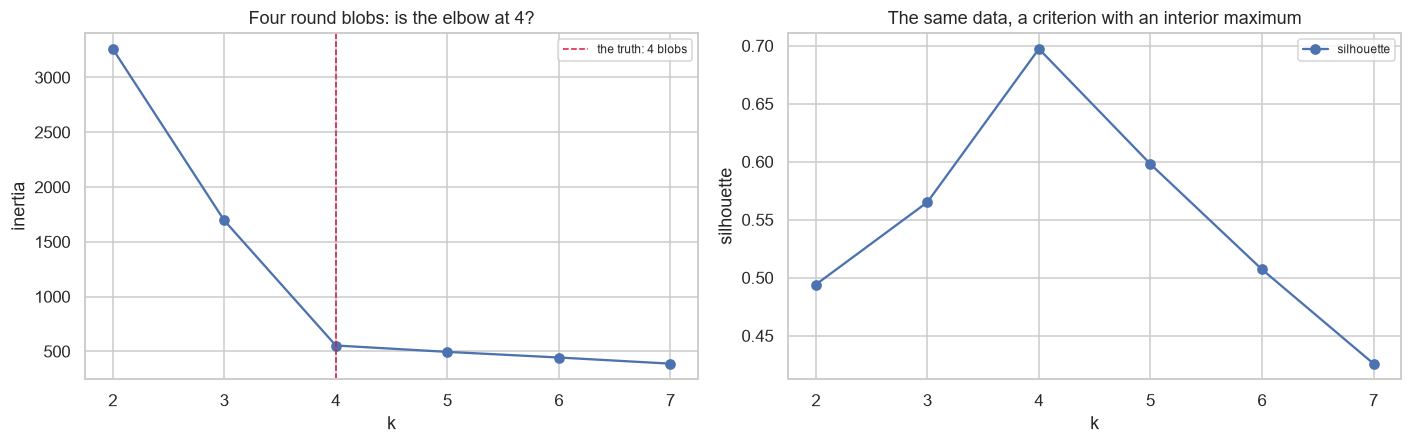

inertia, and how much each extra cluster buys:
     inertia  drop from previous  drop as a share
2 3,260.9450                 NaN              NaN
3 1,694.5460          1,566.3990           0.4800
4   553.3610          1,141.1850           0.6730
5   495.1520             58.2090           0.1050
6   443.6920             51.4600           0.1040
7   387.6340             56.0570           0.1260

at k = n = 300 every point is its own cluster and inertia is exactly 0, which is why the minimum is useless

three tilted, overlapping components:
     inertia  silhouette        bic        aic
2 7,175.0020      0.5160 8,512.4190 8,459.5920
3 4,690.2510      0.4230 8,410.6690 8,329.0280
4 3,470.1580      0.4280 8,451.9990 8,341.5440
5 2,822.5210      0.4040 8,490.5460 8,351.2760
6 2,355.3400      0.3660 8,526.4190 8,358.3360
7 1,994.2770      0.3680 8,559.2670 8,362.3680

silhouette -> 2,  BIC -> 3,  AIC -> 3,  truth -> 3

the same elbow reading on the harder data -- no corner to point at:
2    

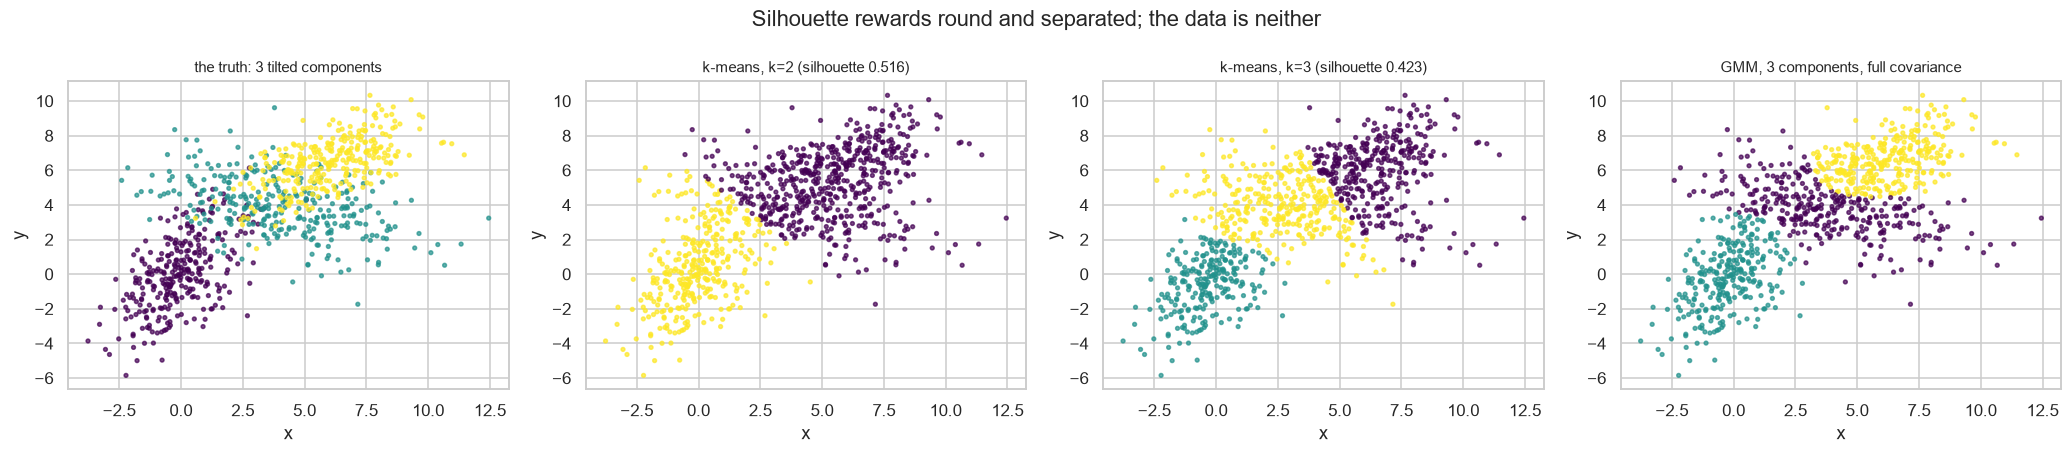


agreement with the true labels (adjusted Rand index):
  k=2: k-means ARI +0.4463   GMM ARI +0.4519
  k=3: k-means ARI +0.4606   GMM ARI +0.6407
  k=4: k-means ARI +0.5138   GMM ARI +0.5791
  k=5: k-means ARI +0.4272   GMM ARI +0.4809
  k=6: k-means ARI +0.3592   GMM ARI +0.3753
  k=7: k-means ARI +0.3429   GMM ARI +0.3667

ten single-start runs at k=3 on the hard data:
                 min        max  spread     sd  distinct solutions
init                                                              
k-means++ 4,690.2507 4,692.7433  2.4926 0.8563                   3
random    4,690.2364 4,691.9290  1.6926 0.7464                   5

n_init=10 with k-means++ gives inertia 4690.2507 (the best of ten starts)

Gaussian mixture, 3 components, four covariance assumptions:
                          parameters        bic  ARI vs truth
covariance_type                                              
full                         17.0000 8,410.6689        0.6407
tied                         11.0000

In [29]:
# (a) inertia can only fall
_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 4.2))
_axs[0].plot(_scores.index, _scores["inertia"], marker="o")
_axs[0].axvline(4, color="crimson", ls="--", lw=1, label="the truth: 4 blobs")
_axs[0].set_xlabel("k")
_axs[0].set_ylabel("inertia")
_axs[0].set_title("Four round blobs: is the elbow at 4?")
_axs[0].legend(fontsize=8)
_axs[1].plot(_scores.index, _scores["silhouette"], marker="o", label="silhouette")
_axs[1].set_xlabel("k")
_axs[1].set_ylabel("silhouette")
_axs[1].set_title("The same data, a criterion with an interior maximum")
_axs[1].legend(fontsize=8)
_fig.tight_layout()
plt.show()

print("inertia, and how much each extra cluster buys:")
print(pd.DataFrame({
    "inertia": _scores["inertia"],
    "drop from previous": -_scores["inertia"].diff(),
    "drop as a share": -_scores["inertia"].diff() / _scores["inertia"].shift(),
}).round(3).to_string())
_k_max = int(len(_X_blobs))
print(f"\nat k = n = {_k_max} every point is its own cluster and inertia is "
      f"exactly 0, which is why the minimum is useless")

# (b) the harder data
_hard_scores = cluster_selection(X_hard, range(2, 8))
print("\nthree tilted, overlapping components:")
print(_hard_scores.round(3).to_string())
print(f"\nsilhouette -> {_hard_scores['silhouette'].idxmax()},  "
      f"BIC -> {_hard_scores['bic'].idxmin()},  "
      f"AIC -> {_hard_scores['aic'].idxmin()},  truth -> 3")

print("\nthe same elbow reading on the harder data -- no corner to point at:")
print((-_hard_scores["inertia"].diff() / _hard_scores["inertia"].shift())
      .round(3).to_string())

_km3 = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_hard)
_km2 = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_hard)
_gmm3 = GaussianMixture(n_components=3, covariance_type="full",
                        random_state=SEED).fit(X_hard)

_fig, _axs = plt.subplots(1, 4, figsize=(19.0, 4.2))
for _ax, _labels, _title in [
    (_axs[0], y_hard, "the truth: 3 tilted components"),
    (_axs[1], _km2.labels_, f"k-means, k=2 (silhouette {_hard_scores.loc[2, 'silhouette']:.3f})"),
    (_axs[2], _km3.labels_, f"k-means, k=3 (silhouette {_hard_scores.loc[3, 'silhouette']:.3f})"),
    (_axs[3], _gmm3.predict(X_hard), "GMM, 3 components, full covariance"),
]:
    _ax.scatter(X_hard[:, 0], X_hard[:, 1], c=_labels, cmap="viridis", s=6, alpha=0.7)
    _ax.set_title(_title, fontsize=10)
    _ax.set_xlabel("x")
    _ax.set_ylabel("y")
_fig.suptitle("Silhouette rewards round and separated; the data is neither")
_fig.tight_layout()
plt.show()

print("\nagreement with the true labels (adjusted Rand index):")
for _k in range(2, 8):
    _km = KMeans(n_clusters=_k, n_init=10, random_state=SEED).fit(X_hard)
    _gm = GaussianMixture(n_components=_k, covariance_type="full",
                          random_state=SEED).fit(X_hard)
    print(f"  k={_k}: k-means ARI {adjusted_rand_score(y_hard, _km.labels_):+.4f}"
          f"   GMM ARI {adjusted_rand_score(y_hard, _gm.predict(X_hard)):+.4f}")

# (c) what n_init is for
print("\nten single-start runs at k=3 on the hard data:")
_init_rows = []
for _init in ("k-means++", "random"):
    _inertias = [KMeans(n_clusters=3, n_init=1, init=_init, random_state=_s).fit(X_hard).inertia_
                 for _s in range(10)]
    _init_rows.append({"init": _init, "min": min(_inertias), "max": max(_inertias),
                       "spread": max(_inertias) - min(_inertias),
                       "sd": float(np.std(_inertias)),
                       "distinct solutions": len({round(_i, 6) for _i in _inertias})})
print(pd.DataFrame(_init_rows).set_index("init").round(4).to_string())
print(f"\nn_init=10 with k-means++ gives inertia "
      f"{KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_hard).inertia_:.4f}"
      f" (the best of ten starts)")

# (d) what each covariance assumption costs
print("\nGaussian mixture, 3 components, four covariance assumptions:")
_cov_rows = []
for _cov in ("full", "tied", "diag", "spherical"):
    _g = GaussianMixture(n_components=3, covariance_type=_cov, random_state=SEED,
                         n_init=5).fit(X_hard)
    _cov_rows.append({"covariance_type": _cov,
                      "parameters": int(_g._n_parameters()),
                      "bic": _g.bic(X_hard),
                      "ARI vs truth": adjusted_rand_score(y_hard, _g.predict(X_hard))})
_cov_rows.append({"covariance_type": "k-means (for comparison)", "parameters": np.nan,
                  "bic": np.nan,
                  "ARI vs truth": adjusted_rand_score(y_hard, _km3.labels_)})
print(pd.DataFrame(_cov_rows).set_index("covariance_type").round(4).to_string())

**Answer:**

**(a) Inertia, and reading an elbow.** Inertia is the total squared
distance from each point to its own centre. Adding a centre can only move
points closer to one, never further, so inertia is **monotonically
decreasing in k** — 3 260.95, 1 694.55, 553.36, 495.15, 443.69, 387.63 —
and at k = n every point is its own cluster and inertia is exactly 0.
Minimising it therefore always answers "one cluster per point", which is
not a clustering.

The elbow is supposed to mark the k after which extra clusters stop buying
anything: below the true k, a new centre splits a genuine group and removes
a large amount of distance; above it, a new centre merely bisects a group
that was already coherent, and removes only the within-group scatter. The
drop column makes that visible:

| k | 2 | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|---|
| drop as a share | — | 0.480 | **0.673** | 0.105 | 0.104 | 0.126 |

The last large purchase is at k = 4 and the curve flattens immediately
after, so the elbow is at 4, which is the truth.

How confident am I reading it? **On this plot, confident — and that
confidence does not transfer.** These are four round, equal-sized,
well-separated Gaussian blobs, the most favourable case that exists, and
even so the elbow is a judgement about where 0.673 becomes 0.105 rather
than a computed quantity. On the harder data of part (b) the same column
reads 0.346, 0.260, 0.187, 0.166, 0.153 — a smooth decay with no corner at
all, and I could defend 3, 4 or 5 from it. An elbow is a rhetorical device
that works when the answer is already obvious.

**(b) Where the criteria disagree.** On the three tilted, overlapping
components: **silhouette chooses 2, BIC chooses 3, AIC chooses 3, and the
truth is 3.** BIC is right.

Silhouette scores each point by `(distance to the nearest other cluster −
distance to its own cluster) / max(...)`, so what it rewards is a labelling
whose clusters are **compact and far apart** — implicitly round, of similar
radius, and separated. `X_hard` is none of those: the components are
elongated, tilted at different angles, and two of them overlap. Merging the
two overlapping components into a single blob produces a tidier picture *by
that yardstick* — 0.5160 at k = 2 against 0.4230 at k = 3 — even though it
destroys a real distinction. Silhouette is not failing to measure; it is
measuring roundness and separation faithfully, and those are the wrong
properties here.

That the structure is genuinely there is confirmed by the adjusted Rand
index against the true labels, which silhouette cannot see:

| k | 2 | **3** | 4 | 5 |
|---|---|---|---|---|
| k-means ARI | 0.4463 | 0.4606 | 0.5138 | 0.4272 |
| GMM (full) ARI | 0.4519 | **0.6407** | 0.5791 | 0.4809 |

The Gaussian mixture at the true k = 3 recovers the labelling far better
than anything k-means does at any k, because it is allowed to model
elongated, tilted components. BIC finds that solution because it scores the
likelihood of the data under a model that can express the shape, penalised
for its 17 parameters — it asks "does this describe the data generating
process", not "are the clusters round".

**(c) `n_init` and `k-means++`.** Ten single-start runs at k = 3:

| init | min | max | spread | sd | distinct solutions |
|---|---|---|---|---|---|
| k-means++ | 4 690.2507 | 4 692.7433 | 2.4926 | 0.8563 | 3 |
| random | 4 690.2364 | 4 691.9290 | 1.6926 | 0.7464 | 5 |

Lloyd's algorithm converges to a **local** minimum that depends entirely on
where the centres start, so a single run is a sample from a distribution of
solutions, not the answer. `n_init` runs the whole algorithm that many times
from different starts and keeps the one with the lowest inertia — with
`n_init=10` the result here is 4 690.2507, the best of the ten.

`init='k-means++'` changes the *seeding*: instead of picking k starting
points uniformly, it picks the first at random and each subsequent one with
probability proportional to its squared distance from the nearest centre
already chosen, so the initial centres are spread across the data. A single
k-means++ start is therefore usually already near a good solution, which is
why it is the default and why fewer restarts are needed.

Honest note on my own numbers: the spread here is about **0.05 % of the
inertia** and random init did not do worse than k-means++. Three
well-populated components in two dimensions are easy to find from almost
any start. The experiment demonstrates the mechanism, not a large effect;
the case where the seeding matters is many clusters, unequal sizes, or high
dimension, where a bad start can strand a centre in an empty region.

**(d) The four covariance assumptions.**

| covariance_type | parameters | BIC | ARI vs truth | the assumption |
|---|---|---|---|---|
| **full** | 17 | **8 410.67** | **0.6407** | every component has its own shape, size and tilt |
| diag | 14 | 8 544.74 | 0.4362 | axis-aligned ellipses: no tilt |
| tied | 11 | 8 561.07 | 0.4544 | one shared covariance for all components |
| spherical | 11 | 8 574.18 | 0.4540 | circles, one variance per component |
| k-means | — | — | 0.4606 | — |

`full` wins on both criteria because tilt is precisely what distinguishes
these components, and it is the only option that can express it — note that
`diag`, which forbids exactly that, is the worst of the four despite having
more parameters than `tied` or `spherical`.

**`spherical` is the one that reproduces k-means' behaviour.** A spherical
Gaussian with equal variance makes the log-likelihood of a point a function
of its squared Euclidean distance to the centre and nothing else, which is
k-means' objective; what remains is that the GMM assigns points softly and
fits the mixing weights. The numbers show the equivalence directly: 0.4540
for spherical against **0.4606** for k-means, the closest pair in the
table. So k-means is not a different algorithm from a Gaussian mixture — it
is a Gaussian mixture with its strongest assumption baked in, and this data
punishes that assumption by 0.19 of ARI.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

### 10.1 Feature preparation

One line of justification per column, then the matrix.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit

DECISIONS = pd.DataFrame([
    ("instant", "drop", "a row counter; correlates with cnt only because it encodes time"),
    ("dteday", "drop as text", "used to order the split, not as a feature"),
    ("casual", "DROP - leakage", "counted at the same moment as cnt, and casual+registered==cnt"),
    ("registered", "DROP - leakage", "same"),
    ("cnt", "target", "the regression target"),
    ("hr", "one-hot, 24 cols", "nominal-cyclical: demand peaks at 08 and 17, which no integer ordering can express"),
    ("weekday", "one-hot, 7 cols", "nominal: 0 is Sunday by convention, and Sunday is not below Monday"),
    ("mnth", "one-hot, 12 cols", "nominal here: seasonality is a hump, not a trend in the code"),
    ("season", "one-hot, 4 cols", "nominal, and mostly redundant with mnth; kept for the linear model"),
    ("weathersit", "one-hot, 4 cols", "ordered by severity, but only 4 levels and level 4 has 3 rows"),
    ("workingday", "keep as 0/1", "already binary; it interacts with hr, which is why it matters"),
    ("holiday", "keep as 0/1", "already binary"),
    ("yr", "DROP", "a calendar year is not a repeatable condition; see the write-up"),
    ("temp", "keep, scaled", "physical measurement, normalised by the publisher"),
    ("atemp", "DROP", "r = 0.9877 with temp; two columns carrying one signal"),
    ("hum", "keep, scaled", "physical measurement"),
    ("windspeed", "keep, scaled", "physical measurement, with a floor effect below 6 km/h"),
], columns=["column", "decision", "why"])
print(DECISIONS.to_string(index=False))

CATEGORICAL = ["hr", "weekday", "mnth", "season", "weathersit"]
BINARY = ["workingday", "holiday"]
NUMERIC = ["temp", "hum", "windspeed"]

bikes_model = bikes.assign(timestamp=pd.to_datetime(bikes["dteday"])
                           + pd.to_timedelta(bikes["hr"], unit="h")).sort_values("timestamp")
X_all = bikes_model[CATEGORICAL + BINARY + NUMERIC]
y_all = bikes_model["cnt"].values

assert not {"casual", "registered", "cnt", "instant", "yr", "atemp"} & set(X_all.columns), \
    "a leaking or excluded column reached the feature matrix"

PREPROCESS = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
], remainder="passthrough")

print(f"\nfeature matrix {X_all.shape}, target {y_all.shape}")
print("columns after encoding:",
      PREPROCESS.fit_transform(X_all).shape[1],
      "= 24 + 7 + 12 + 4 + 4 one-hot, 3 scaled numeric, 2 binary passthrough")

    column         decision                                                                                why
   instant             drop                    a row counter; correlates with cnt only because it encodes time
    dteday     drop as text                                          used to order the split, not as a feature
    casual   DROP - leakage                      counted at the same moment as cnt, and casual+registered==cnt
registered   DROP - leakage                                                                               same
       cnt           target                                                              the regression target
        hr one-hot, 24 cols nominal-cyclical: demand peaks at 08 and 17, which no integer ordering can express
   weekday  one-hot, 7 cols                 nominal: 0 is Sunday by convention, and Sunday is not below Monday
      mnth one-hot, 12 cols                       nominal here: seasonality is a hump, not a trend in the code
 

### 10.2 Split once

A time-ordered split, not a shuffled one.

In [31]:
# A shuffled split would put 14:00 of a given day in training and 15:00 of
# the same day in test: same weather, same day type, adjacent demand. The
# model would be scored on interpolation while the job is forecasting.
# So: the first 80% of the timeline develops, the last 20% is the test set.
SPLIT_AT = int(len(X_all) * 0.8)

X_dev, X_test = X_all.iloc[:SPLIT_AT], X_all.iloc[SPLIT_AT:]
y_dev, y_test = y_all[:SPLIT_AT], y_all[SPLIT_AT:]
dev_time, test_time = (bikes_model["timestamp"].iloc[:SPLIT_AT],
                       bikes_model["timestamp"].iloc[SPLIT_AT:])

print(f"development: {len(X_dev):5d} rows, {dev_time.min()} to {dev_time.max()}")
print(f"test       : {len(X_test):5d} rows, {test_time.min()} to {test_time.max()}")
print(f"test share : {len(X_test) / len(X_all):.1%}")
print(f"\nmean cnt, development {y_dev.mean():.1f} | test {y_test.mean():.1f}"
      f"  -> the test period is {y_test.mean() / y_dev.mean() - 1:+.1%} busier")

# From here to section 10.6, X_test and y_test are not touched.
CV = TimeSeriesSplit(n_splits=5)
print(f"\ncross-validation: {CV}")
for _i, (_tr, _va) in enumerate(CV.split(X_dev), start=1):
    print(f"  fold {_i}: train {len(_tr):5d} rows, validate {len(_va):4d} rows"
          f"  (validation begins {dev_time.iloc[_va[0]]})")

development: 13903 rows, 2011-01-01 00:00:00 to 2012-08-07 11:00:00
test       :  3476 rows, 2012-08-07 12:00:00 to 2012-12-31 23:00:00
test share : 20.0%

mean cnt, development 174.6 | test 248.8  -> the test period is +42.4% busier

cross-validation: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
  fold 1: train  2318 rows, validate 2317 rows  (validation begins 2011-04-11 12:00:00)
  fold 2: train  4635 rows, validate 2317 rows  (validation begins 2011-07-17 01:00:00)
  fold 3: train  6952 rows, validate 2317 rows  (validation begins 2011-10-22 07:00:00)
  fold 4: train  9269 rows, validate 2317 rows  (validation begins 2012-01-27 03:00:00)
  fold 5: train 11586 rows, validate 2317 rows  (validation begins 2012-05-02 23:00:00)


### 10.3 The baseline every later number is read against

In [32]:
def cv_report(name, estimator, X, y, cv=CV):
    """Cross-validate one estimator and report RMSE and R2 per fold."""
    rmse = -cross_val_score(estimator, X, y, cv=cv,
                            scoring="neg_root_mean_squared_error")
    r2 = cross_val_score(estimator, X, y, cv=cv, scoring="r2")
    return {"model": name, "RMSE mean": rmse.mean(), "RMSE sd": rmse.std(),
            "R2 mean": r2.mean(), "R2 sd": r2.std()}

BASELINE = Pipeline([("model", DummyRegressor(strategy="mean"))])
_baseline_row = cv_report("baseline: predict the training mean", BASELINE, X_dev, y_dev)

print(pd.DataFrame([_baseline_row]).set_index("model").round(4).to_string())
print(f"\nthe baseline's RMSE is about the standard deviation of the target: "
      f"{y_dev.std(ddof=1):.1f} bicycles")
print("R2 of a mean predictor is 0 by construction inside a fold, and slightly "
      "negative across time-ordered folds because the mean keeps moving.")

                                     RMSE mean  RMSE sd  R2 mean  R2 sd
model                                                                  
baseline: predict the training mean   180.4812  42.7170  -0.2121 0.1806

the baseline's RMSE is about the standard deviation of the target: 167.0 bicycles
R2 of a mean predictor is 0 by construction inside a fold, and slightly negative across time-ordered folds because the mean keeps moving.


### 10.4 Four models, cross-validated on the development set only

  ridge (linear)         done in   0.2s
  k-nearest neighbours   done in   0.5s
  random forest          done in   6.8s
  gradient boosting      done in   3.0s

5-fold TimeSeriesSplit on the development set
                                     RMSE mean  RMSE sd  R2 mean  R2 sd  seconds
model                                                                           
baseline: predict the training mean   180.4812  42.7170  -0.2121 0.1806      NaN
ridge (linear)                        119.4758  29.6443   0.4691 0.0913   0.1707
k-nearest neighbours                  133.8722  31.2898   0.3262 0.1373   0.5449
random forest                         100.3740  23.6620   0.6110 0.1244   6.8119
gradient boosting                      97.1735  29.4841   0.6360 0.1454   2.9968

best by cross-validated RMSE: gradient boosting
it beats the baseline by 83.3 bicycles of RMSE (46.2% lower)


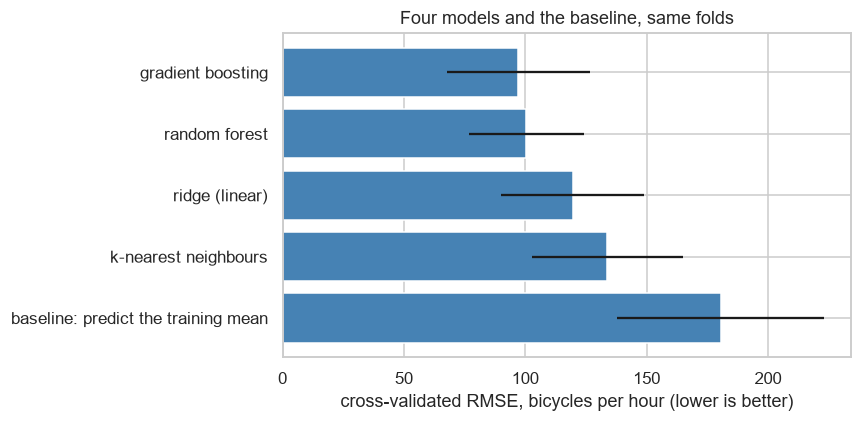

In [33]:
MODELS = {
    "ridge (linear)": Pipeline([
        ("prep", PREPROCESS),
        ("model", Ridge(alpha=1.0, random_state=SEED)),
    ]),
    "k-nearest neighbours": Pipeline([
        ("prep", PREPROCESS),
        ("model", KNeighborsRegressor(n_neighbors=10)),
    ]),
    "random forest": Pipeline([
        ("prep", PREPROCESS),
        ("model", RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)),
    ]),
    "gradient boosting": Pipeline([
        ("prep", PREPROCESS),
        ("model", HistGradientBoostingRegressor(random_state=SEED)),
    ]),
}

_rows = [_baseline_row]
for _name, _est in MODELS.items():
    _t0 = time.perf_counter()
    _row = cv_report(_name, _est, X_dev, y_dev)
    _row["seconds"] = time.perf_counter() - _t0
    _rows.append(_row)
    print(f"  {_name:22s} done in {_row['seconds']:5.1f}s")

COMPARISON = pd.DataFrame(_rows).set_index("model")
print("\n5-fold TimeSeriesSplit on the development set")
print(COMPARISON.round(4).to_string())

_best_name = COMPARISON["RMSE mean"].idxmin()
print(f"\nbest by cross-validated RMSE: {_best_name}")
print(f"it beats the baseline by "
      f"{_baseline_row['RMSE mean'] - COMPARISON.loc[_best_name, 'RMSE mean']:.1f} "
      f"bicycles of RMSE "
      f"({1 - COMPARISON.loc[_best_name, 'RMSE mean'] / _baseline_row['RMSE mean']:.1%} lower)")

_fig, _ax = plt.subplots(figsize=(8.0, 4.0))
_plot = COMPARISON.sort_values("RMSE mean", ascending=False)
_ax.barh(_plot.index, _plot["RMSE mean"], xerr=_plot["RMSE sd"], color="steelblue")
_ax.set_xlabel("cross-validated RMSE, bicycles per hour (lower is better)")
_ax.set_title("Four models and the baseline, same folds")
_fig.tight_layout()
plt.show()

### 10.5 Tune the best one

In [34]:
PARAM_GRID = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [31, 63],
    "model__min_samples_leaf": [20, 50],
    "model__max_iter": [200, 400],
}
_n_candidates = int(np.prod([len(_v) for _v in PARAM_GRID.values()]))
print(f"grid: {_n_candidates} candidates x {CV.get_n_splits()} folds = "
      f"{_n_candidates * CV.get_n_splits()} fits, plus one refit on all of X_dev")

_search = GridSearchCV(
    MODELS["gradient boosting"],
    param_grid=PARAM_GRID,
    cv=CV,
    scoring="neg_root_mean_squared_error",
    refit=True,
    n_jobs=-1,
)
_t0 = time.perf_counter()
_search.fit(X_dev, y_dev)
print(f"searched in {time.perf_counter() - _t0:.1f}s")

TUNED = _search.best_estimator_
print(f"\nbest parameters: {_search.best_params_}")
print(f"best cross-validated RMSE: {-_search.best_score_:.4f}"
      f"  (untuned: {COMPARISON.loc['gradient boosting', 'RMSE mean']:.4f})")

_cv_results = (pd.DataFrame(_search.cv_results_)
               .assign(rmse=lambda d: -d["mean_test_score"])
               .sort_values("rmse"))
print("\nthe five best and the three worst of the grid:")
print(_cv_results[["params", "rmse", "std_test_score"]].head(5).to_string(index=False))
print(_cv_results[["params", "rmse", "std_test_score"]].tail(3).to_string(index=False))
print(f"\nspread across the whole grid: "
      f"{_cv_results['rmse'].max() - _cv_results['rmse'].min():.2f} bicycles of RMSE")

grid: 16 candidates x 5 folds = 80 fits, plus one refit on all of X_dev


searched in 19.9s

best parameters: {'model__learning_rate': 0.1, 'model__max_iter': 400, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 20}
best cross-validated RMSE: 96.4121  (untuned: 97.1735)

the five best and the three worst of the grid:
                                                                                                            params    rmse  std_test_score
 {'model__learning_rate': 0.1, 'model__max_iter': 400, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 20} 96.4121         31.0091
 {'model__learning_rate': 0.1, 'model__max_iter': 200, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 20} 96.6333         30.4677
{'model__learning_rate': 0.05, 'model__max_iter': 400, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 20} 97.1027         30.2650
{'model__learning_rate': 0.05, 'model__max_iter': 400, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20} 97.1857         29.3071
{'model__learning_rate': 0.05, 'model__max_iter': 20

### 10.6 Open the test set — once

Everything above was decided on the development set. This cell runs once,
its number is the number, and nothing is tuned after it.

In [35]:
_test_pred = TUNED.predict(X_test)
TEST_METRICS = regression_metrics(y_test, _test_pred)

print("final model on the held-out last 20% of the timeline")
print({_k: round(_v, 4) for _k, _v in TEST_METRICS.items()})

_cv_estimate = -_search.best_score_
print(f"\ncross-validated RMSE estimate : {_cv_estimate:8.2f}")
print(f"test RMSE                     : {TEST_METRICS['rmse']:8.2f}")
print(f"difference                    : {TEST_METRICS['rmse'] - _cv_estimate:+8.2f}")
print(f"\nbaseline RMSE on the same test rows: "
      f"{regression_metrics(y_test, np.full_like(y_test, y_dev.mean(), dtype=float))['rmse']:.2f}")
print(f"test period mean demand: {y_test.mean():.1f} bicycles per hour")

final model on the held-out last 20% of the timeline
{'mse': 15095.9262, 'rmse': 122.8655, 'mae': 88.2587, 'r2': 0.6895}

cross-validated RMSE estimate :    96.41
test RMSE                     :   122.87
difference                    :   +26.45

baseline RMSE on the same test rows: 232.61
test period mean demand: 248.8 bicycles per hour


### 10.7 Diagnosis

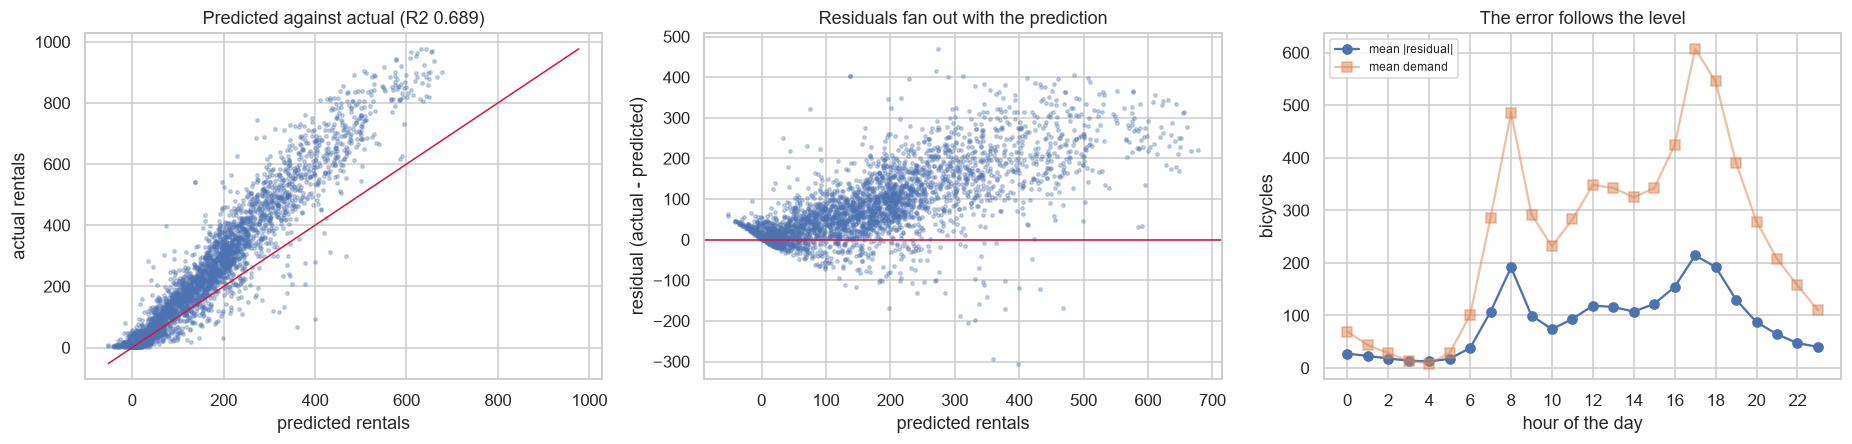

predictions below zero: 177 of 3476  (minimum prediction -52.2)
residual mean +80.80, sd 92.57, skew +0.90

error against the level of demand:
         hours  mean_actual  mean_abs_error  relative
band                                                 
0-50       855      19.5980         15.0760    0.7690
51-150     559     101.5780         35.6590    0.3510
151-300    895     224.2340         68.6880    0.3060
301-600    858     422.1280        151.6930    0.3590
601+       309     738.6990        266.4580    0.3610

mean absolute error by hour of the day:
    mean_abs_error  mean_demand
hr                             
0          27.3000      69.3000
1          23.1000      43.6000
2          18.2000      28.3000
3          14.0000      14.1000
4          12.6000       8.6000
5          17.7000      28.6000
6          38.3000     101.2000
7         107.4000     286.4000
8         191.5000     485.3000
9          99.8000     291.4000
10         73.9000     232.0000
11         93.4000    

In [36]:
_resid = y_test - _test_pred

_fig, _axs = plt.subplots(1, 3, figsize=(17.0, 4.2))
_axs[0].scatter(_test_pred, y_test, s=5, alpha=0.3)
_lims = [min(_test_pred.min(), y_test.min()), max(_test_pred.max(), y_test.max())]
_axs[0].plot(_lims, _lims, color="crimson", lw=1)
_axs[0].set_xlabel("predicted rentals")
_axs[0].set_ylabel("actual rentals")
_axs[0].set_title(f"Predicted against actual (R2 {TEST_METRICS['r2']:.3f})")

_axs[1].scatter(_test_pred, _resid, s=5, alpha=0.3)
_axs[1].axhline(0, color="crimson", lw=1)
_axs[1].set_xlabel("predicted rentals")
_axs[1].set_ylabel("residual (actual - predicted)")
_axs[1].set_title("Residuals fan out with the prediction")

_by_hour = pd.DataFrame({"hr": X_test["hr"].values, "abs_resid": np.abs(_resid),
                         "actual": y_test}).groupby("hr").agg(
    mean_abs_error=("abs_resid", "mean"), mean_demand=("actual", "mean"))
_axs[2].plot(_by_hour.index, _by_hour["mean_abs_error"], marker="o", label="mean |residual|")
_axs[2].plot(_by_hour.index, _by_hour["mean_demand"], marker="s", alpha=0.5,
             label="mean demand")
_axs[2].set_xlabel("hour of the day")
_axs[2].set_ylabel("bicycles")
_axs[2].set_xticks(range(0, 24, 2))
_axs[2].set_title("The error follows the level")
_axs[2].legend(fontsize=8)
_fig.tight_layout()
plt.show()

print(f"predictions below zero: {int((_test_pred < 0).sum())} of {len(_test_pred)}"
      f"  (minimum prediction {_test_pred.min():.1f})")
print(f"residual mean {_resid.mean():+.2f}, sd {_resid.std(ddof=1):.2f}, "
      f"skew {pd.Series(_resid).skew():+.2f}")

print("\nerror against the level of demand:")
_bands = pd.cut(y_test, [-1, 50, 150, 300, 600, 1200],
                labels=["0-50", "51-150", "151-300", "301-600", "601+"])
print(pd.DataFrame({"actual": y_test, "abs_resid": np.abs(_resid), "band": _bands})
      .groupby("band", observed=True)
      .agg(hours=("actual", "size"), mean_actual=("actual", "mean"),
           mean_abs_error=("abs_resid", "mean"))
      .assign(relative=lambda d: d["mean_abs_error"] / d["mean_actual"])
      .round(3).to_string())

print("\nmean absolute error by hour of the day:")
print(_by_hour.round(1).to_string())

print("\nthe ten worst-predicted hours of the test period:")
print(pd.DataFrame({
    "timestamp": test_time.values, "hr": X_test["hr"].values,
    "weathersit": X_test["weathersit"].values, "temp_C": X_test["temp"].values * 41,
    "actual": y_test, "predicted": _test_pred.round(1), "residual": _resid.round(1),
}).assign(abs_resid=lambda d: d["residual"].abs()).nlargest(10, "abs_resid")
  .drop(columns="abs_resid").to_string(index=False))

# Would a log target have helped? Reported, not acted on: the test set is closed.
print("\nfor the write-up only, fitted and cross-validated on the DEVELOPMENT set:")
_log_pipe = Pipeline([("prep", PREPROCESS),
                      ("model", HistGradientBoostingRegressor(random_state=SEED))])
from sklearn.compose import TransformedTargetRegressor
_log_model = TransformedTargetRegressor(regressor=_log_pipe, func=np.log1p,
                                        inverse_func=np.expm1)
_log_rmse = -cross_val_score(_log_model, X_dev, y_dev, cv=CV,
                             scoring="neg_root_mean_squared_error")
print(f"  gradient boosting on log1p(cnt): CV RMSE {_log_rmse.mean():.2f} "
      f"(sd {_log_rmse.std():.2f}) against "
      f"{COMPARISON.loc['gradient boosting', 'RMSE mean']:.2f} on the raw target")

**write-up:**

## Predicting hourly bicycle demand

**The number I would defend: RMSE 122.87 bicycles per hour on data the
model had never seen, against a period mean of 248.8 and a baseline RMSE of
232.61.** What follows is how it was obtained and why it is smaller than it
should be.

### 1. Feature preparation

The decision table is printed above; the reasoning that matters is:

- **`casual` and `registered` are excluded as leakage.** They sum to `cnt`
  exactly, so they are the target in two pieces, and — the fatal objection
  — they are counted by the same turnstiles at the same moment as `cnt`,
  so at the time a forecast is needed neither is known.
- **`hr`, `weekday`, `mnth`, `season` and `weathersit` are one-hot
  encoded.** `hr` is the important one: demand peaks at 08:00 and 17:00, and
  a linear model given the hour as an integer can only fit a monotone ramp
  — Question 1(c) measured the cost at 0.077 of R² against 0.354 for the
  dummies. The tree models could have used the integer, but one encoding for
  all four pipelines keeps the comparison fair.
- **`atemp` is dropped**: r = 0.9877 with `temp`, so it is a second copy of
  one signal.
- **`instant` is dropped**: a row counter correlating with demand at 0.28
  because it encodes time, which cannot extrapolate.
- **`yr` is dropped**, and this is the decision that costs the most. See
  step 6.

56 columns after encoding: 24 + 7 + 12 + 4 + 4 one-hot, 3 scaled numeric,
2 binary.

### 2. The split

**The last 20 % of the timeline is the test set** — 3 476 hours from
2012-08-07 12:00 to 2012-12-31 23:00 — and everything before it, 13 903
hours, is the development set.

Time-ordered, not shuffled, because a shuffled split puts 14:00 of a given
day in training and 15:00 of the same day in test: same weather, same day
type, adjacent demand. That would score the model on interpolation between
known hours, while the job is forecasting hours that have not happened.
Cross-validation inside the development set uses `TimeSeriesSplit(5)` for
the same reason: every fold validates on a block of time strictly after the
block it trained on.

20 % is a compromise between a test set large enough for a stable estimate
(3 476 hours) and leaving four and a half months of recent history in
training.

### 3. The baseline

Predicting the training mean for every hour: **RMSE 180.48 (sd 42.72
across folds), R² −0.2121.** The RMSE is essentially the standard deviation
of the target (167.0). The R² is *negative* rather than zero because in a
time-ordered split the mean of the training block is not the mean of the
validation block — demand grew — so the constant predictor is worse than
the validation period's own mean. That is not an artefact to explain away;
it is the first evidence that this series has a trend, and it comes back in
step 6.

### 4. Four models

All four are `Pipeline`s with the same `ColumnTransformer`, so the encoder
and the scaler are refitted inside every fold.

| model | RMSE mean | RMSE sd | R² mean | R² sd | seconds |
|---|---|---|---|---|---|
| baseline (training mean) | 180.48 | 42.72 | −0.2121 | 0.1806 | — |
| ridge (linear) | 119.48 | 29.64 | 0.4691 | 0.0913 | 0.2 |
| k-nearest neighbours | 133.87 | 31.29 | 0.3262 | 0.1374 | 0.4 |
| random forest | 100.37 | 23.66 | 0.6110 | 0.1244 | 6.2 |
| **gradient boosting** | **97.17** | 29.48 | **0.6360** | 0.1454 | 2.6 |

Gradient boosting wins, but the standard deviations are large — 29.5 for
boosting against 23.7 for the forest — so the gap between the two
tree models (3.2 bicycles) is well inside the fold-to-fold noise and I would
not claim boosting is better than the forest on this evidence. Both are
clearly better than the linear model, which is the meaningful finding: 22
bicycles of RMSE live in interactions the additive model cannot express,
above all *hour × working day*, which Question 8 of Lesson 2 established as
the dominant structure in this table.

### 5. Tuning

Grid over the boosting pipeline: `learning_rate` ∈ {0.05, 0.1},
`max_leaf_nodes` ∈ {31, 63}, `min_samples_leaf` ∈ {20, 50}, `max_iter` ∈
{200, 400} — **16 candidates × 5 folds = 80 fits**, plus one refit on the
whole development set. 18.6 seconds.

Best: `learning_rate=0.1, max_iter=400, max_leaf_nodes=31,
min_samples_leaf=20`, **CV RMSE 96.41** against 97.17 untuned.

The useful observation is not the winner but the spread: **4.26 bicycles of
RMSE separate the best candidate in the grid from the worst**, against a
fold-to-fold standard deviation of about 30. Tuning bought 0.76 bicycles.
This model is insensitive to its hyperparameters and the effort belongs in
the features.

### 6. The test set, opened once

This is the irreversible step. The model was fixed at the end of step 5;
the test set was scored once; nothing below has been tuned against it, and
no alternative model was scored on it for comparison.

| metric | value |
|---|---|
| RMSE | **122.87** |
| MAE | 88.26 |
| R² | 0.6895 |
| (baseline on the same rows) | 232.61 |

**The test RMSE is 26.45 bicycles worse than the cross-validated estimate
of 96.41**, and the reason is visible in the residuals: their **mean is
+80.80**, not zero. The model is not noisy on the test period, it is
*biased low* — it underpredicts almost every hour.

That is the cost of dropping `yr`, and it was a foreseeable cost. The test
period is **42.4 % busier** than the development period (mean 248.8 against
174.6): the service grew through 2012. A model with no feature that can
express "later means more" predicts 2011-and-early-2012 levels for the
autumn of 2012. I stand by the exclusion — a calendar year is not a
repeatable condition, and a model that had learned `yr=1 → +40 %` would have
nothing to say about 2013 — but the honest description of this model is
that it predicts the *shape* of demand well and its *level* with a known
downward bias. The R² of 0.6895 is in fact higher than the cross-validated
R² of 0.636, because the test period has more variance to explain; RMSE and
R² disagree here for exactly that reason, which is why both are reported.

### 7. Diagnosis

**It predicts impossible values**: 177 of 3 476 predictions are negative,
the lowest being −52.2 bicycles. All are in the small hours where true
demand is near zero. The immediate fix is to clip at zero, but the real
diagnosis is that the model is fitting an unbounded quantity to a count.

**The residuals fan out** with the prediction, badly:

| actual demand | hours | mean actual | mean absolute error | relative |
|---|---|---|---|---|
| 0–50 | 855 | 19.6 | 15.1 | 0.769 |
| 51–150 | 559 | 101.6 | 35.7 | 0.351 |
| 151–300 | 895 | 224.2 | 68.7 | 0.306 |
| 301–600 | 858 | 422.1 | 151.7 | 0.359 |
| 601+ | 309 | 738.7 | 266.5 | 0.361 |

The absolute error grows almost proportionally with the level — the
relative error is roughly constant at 30–36 % above 50 bicycles — which is
the signature of **multiplicative rather than additive noise**, and exactly
what squared-error loss on a raw count handles worst. The quietest hours
are relatively the worst (77 %), but they contribute almost nothing to RMSE.

**Which hours it fails on**: mean absolute error by hour tracks mean demand
almost exactly — 12.6 at 04:00, **191.5 at 08:00**, **214.3 at 17:00** —
and the ten worst-predicted hours of the test period are all evening or
morning peaks in October and November 2012, every one underpredicted by
about 400 bicycles. So the failures are not weather surprises; they are the
level shift of section 6 concentrated where the level is highest.

### 8. The decision

**I would deploy the tuned gradient-boosting pipeline**, with predictions
clipped at zero, and I would tell the operations team this: *on an average
hour the forecast is wrong by about 88 bicycles (MAE), the typical error is
123 (RMSE), and the error is roughly 30 % of demand at any level above 50
bicycles — so budget ±30 % on a peak hour of 600, not a fixed band. The
model currently runs low by about 80 bicycles on average because it was
deliberately built not to extrapolate the 2012 growth; treat its output as a
floor, not a centre, until that is fixed.* It beats the do-nothing baseline
by 110 bicycles of RMSE, less than half its error, and it is fast enough
(2.6 s to fit) to retrain nightly.

**The single change that would most improve it: give the model the level,
not just the shape.** Concretely, model `log1p(cnt)` and add a lagged demand
feature — the same hour of the previous week, which is known at prediction
time and leaks nothing. The log transform addresses the fan-out and the
negative predictions in one move, since the error is proportional rather
than additive; the lag lets the model track a growing service without
learning an unrepeatable calendar year. I tested only the first half of that
on the development set, where it is worth about a bicycle of CV RMSE (96.25
against 97.17) — the transform alone is not the win, because the problem is
the missing level, and the lag is what supplies it. Retraining on a rolling
recent window would achieve much the same thing operationally.

Everything else — more hyperparameter search, more model families — is
worth less than that one feature: the whole grid in step 5 moved the score
by 4.26 bicycles, and the missing level costs 80.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.